## Table of Contents

- [**Problem Statement**](#problem-statement)
- [Business Context](#business-context)
- [Objective](#objective)
- [Data Description](#data-description)
- [**Installing and Importing the necessary libraries**](#installing-and-importing-the-necessary-libraries)
- [**Loading the Data**](#loading-the-data)
- [Data Overview](#data-overview)
    - [Data Understanding - Training Data](#data-understanding---training-data)
    - [Data Understanding - Test Data](#data-understanding---test-data)
- [Exploratory Data Analysis](#exploratory-data-analysis)
    - [Pairplot for target hue](#pairplot-for-target-hue)
    - [**Obervation Notes:**](#obervation-notes)
    - [Histrogram of the target variable](#histrogram-of-the-target-variable)
    - [Distribution of target variable](#distribution-of-target-variable)
    - [**Observation Notes** : EDA Summary](#observation-notes--eda-summary)
      - [**Impact on 'Target' Variable**](#impact-on-target-variable)
      - [**Inter-Feature Dependencies**](#inter-feature-dependencies)
      - [**Summary**](#summary)
- [**Data Preprocessing**](#data-preprocessing)
    - [Train Validation split](#train-validation-split)
    - [**Observation Notes** :](#observation-notes)
  - [Create Scaled Data](#create-scaled-data)
    - [Compare side-by-side (only shows differences)](#compare-side-by-side-only-shows-differences)
- [**Model Building**](#model-building)
- [Model Building](#model-building)
  - [Regression Models - Linear and Logistic Regression both.](#regression-models---linear-and-logistic-regression-both)
    - [**Observation Notes** :](#observation-notes)
  - [Machine Learning Models](#machine-learning-models)
    - [Display Functions](#display-functions)
    - [Base Models](#base-models)
    - [Create Oversampled and Undersampled data](#create-oversampled-and-undersampled-data)
    - [Over and Undersampling](#over-and-undersampling)
    - [Check results](#check-results)
    - [Hyper Tuning](#hyper-tuning)
  - [Neural Network Models](#neural-network-models)
    - [Model Evaluation Criterion](#model-evaluation-criterion)
    - [**Observation Notes** :](#observation-notes)
    - [](#)
    - [S1 - SGD,relu,H1,O-sig- No class weights, no dropout](#s1---sgdreluh1o-sig--no-class-weights-no-dropout)
    - [S2 - SGD,relu,H1,H2,O-sig- No class weights, no dropout](#s2---sgdreluh1h2o-sig--no-class-weights-no-dropout)
  - [S5D - SGD,relu,H1,D1,H2,D2,H3,O-sig- No class weights](#s5d---sgdreluh1d1h2d2h3o-sig--no-class-weights)
  - [S3 - SGD,relu,H1,H2,H3,O-Sig - No class weights](#s3---sgdreluh1h2h3o-sig---no-class-weights)
  - [Compute Class Weights](#compute-class-weights)
  - [S5D-CW - SGD,relu,H1,D1,H2,D2,H3,O-Sig - class weights](#s5d-cw---sgdreluh1d1h2d2h3o-sig---class-weights)
  - [A2-CW - Adam,relu,H1,H2,O-Sig - class weights](#a2-cw---adamreluh1h2o-sig---class-weights)
  - [A5D-LR-CW - Adam,leaky_relu,H1,D1,H2,D2,H3,O-Sig - class weights](#a5d-lr-cw---adamleakyreluh1d1h2d2h3o-sig---class-weights)
  - [A5D-CW - Adam,relu,H1,D1,H2,D2,H3,O-Sig - class weights](#a5d-cw---adamreluh1d1h2d2h3o-sig---class-weights)
  - [A11D-CW - Adam,Relu,H1,D1,H2,D2,H3,H4,D4,H5,D5,H6,O-Sig - class weights](#a11d-cw---adamreluh1d1h2d2h3h4d4h5d5h6o-sig---class-weights)
  - [AX5D-CW - Adamx,H1,D1,H2,D2,H3,O-Sig - class weights](#ax5d-cw---adamxh1d1h2d2h3o-sig---class-weights)
  - [AX1-CW- Adamx,H1,O-Sig - class weights](#ax1-cw--adamxh1o-sig---class-weights)
  - [AX9D-CW - Adamx,H1,D1,H2,D2,H3,D3,H4,D4,H5,O-Sig - class weights](#ax9d-cw---adamxh1d1h2d2h3d3h4d4h5o-sig---class-weights)
- [**Model Performance Comparison and Final Model Selection**](#model-performance-comparison-and-final-model-selection)
  - [Check output](#check-output)
  - [**Model Performance Comaprision**](#model-performance-comaprision)
    - [Comparison and Performance Analysis](#comparison-and-performance-analysis)
      - [1. The Recall Leaders (False Negative Reduction)](#1-the-recall-leaders-false-negative-reduction)
      - [2. Scaled vs. Unscaled Data](#2-scaled-vs-unscaled-data)
      - [3. Optimizer Impact](#3-optimizer-impact)
    - [The Top Model Selection](#the-top-model-selection)
      - [**AX9D-CW-SCALED**](#ax9d-cw-scaled)
  - [Final Model Checks and Tuning](#final-model-checks-and-tuning)
    - [New Model with AX9D-CW-SCALED hyperparameters.](#new-model-with-ax9d-cw-scaled-hyperparameters)
    - [New Model based on AX9D-CW-SCALED hyper parameters, but increase the number of epochs to 25, and batch size to 100](#new-model-based-on-ax9d-cw-scaled-hyper-parameters-but-increase-the-number-of-epochs-to-25-and-batch-size-to-100)
- [**Actionable Insights and Recommendations**](#actionable-insights-and-recommendations)
    - [Key Observations](#key-observations)
    - [Comparison of Alternative Models](#comparison-of-alternative-models)
      - [Why AX9D-CW-SCALED Won the "Trade-off"](#why-ax9d-cw-scaled-won-the-trade-off)
      - [The "Over-Conservative" Group (SGD Models)](#the-over-conservative-group-sgd-models)
      - [The "Trigger Happy" Group (Small Adamax Models)](#the-trigger-happy-group-small-adamax-models)
- [Appendix](#appendix)
  - [Alternative Approach](#alternative-approach)
    - [Model 0](#model-0)
    - [M1 - SGD - 2 hidden layers (32,16 relu) - 1 output (sigmoid)](#m1---sgd---2-hidden-layers-3216-relu---1-output-sigmoid)
    - [M2 - SGD - 3 hidden layers (32,16,8 relu) - 1 dropout 0.1- 1 output (sigmoid)](#m2---sgd---3-hidden-layers-32168-relu---1-dropout-01--1-output-sigmoid)
    - [M3 - SGD - 3 hidden layers (32,16,8 relu) - 1 dropout 0.1- 1 output (sigmoid) - Class weight](#m3---sgd---3-hidden-layers-32168-relu---1-dropout-01--1-output-sigmoid---class-weight)
    - [M4 - Adam - 2 hidden layers (32,16 relu) - 1 output (sigmoid)](#m4---adam---2-hidden-layers-3216-relu---1-output-sigmoid)
    - [M5 - Adam - 3 hidden layers (32,16,8 relu) - 1 dropout 0.1- 1 output (sigmoid)](#m5---adam---3-hidden-layers-32168-relu---1-dropout-01--1-output-sigmoid)
    - [M6 - Adam - 3 hidden layers (32,16,8 relu) - 1 dropout 0.1- 1 output (sigmoid) - class weights](#m6---adam---3-hidden-layers-32168-relu---1-dropout-01--1-output-sigmoid---class-weights)

# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [1]:
# Installing the libraries with the specified version
#!pip install --no-deps tensorflow==2.19.0 scikit-learn==1.6.1 matplotlib===3.10.0 seaborn==0.13.2 numpy==2.0.2 pandas==2.2.2 -q --user --no-warn-script-location

In [1]:
# Library for data manipulation and analysis.
import pandas as pd
# Fundamental package for scientific computing.
import numpy as np
#splitting datasets into training and testing sets.
from sklearn.model_selection import train_test_split
#Imports tools for data preprocessing including label encoding, one-hot encoding, and standard scaling
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,StandardScaler
#Imports a class for imputing missing values in datasets.
from sklearn.impute import SimpleImputer

#Import  Regression
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

#Import Data Scaler
from sklearn.preprocessing import StandardScaler

#Imports the Matplotlib library for creating visualizations.
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
# Imports the Seaborn library for statistical data visualization.
import seaborn as sns
# Time related functions.
import time
#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
#Imports metrics from
from sklearn import metrics
#For setting the configuration of the scikit-learn library.
from sklearn import set_config

#Imports the tensorflow,keras and layers.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense, Input, Dropout,BatchNormalization
import tensorflow.keras as keras
from tensorflow.keras import backend

import copy
# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Using my own Pythn libraries for Exploratory Data Analysis and Decision Tree Modeling.
## 1. EDA - Exploratory Data Analysis
## 2. DT - Decision Tree
## Easier to write once and use as packaged functions. 
from VKPyKit.EDA import *
from VKPyKit.DT import *
from VKPyKit.MLM import *
from VKPyKit.VKPy import *  

VKPy = VKPy()
EDA= EDA()
DT = DT()
MLM = MLM()

THRESHOLD = 0.5


/Users/vishalkhapre/Documents/Code/AI-ML-Experiments/.venv-metal/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


# **Loading the Data**

In [3]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

df_train = pd.read_csv("Train.csv")
df_test = pd.read_csv("Test.csv")

# Data Overview

#### Data Understanding - Training Data

In [4]:
overview_train = EDA.overview(df_train)  
display("Null values in train data:", df_train.isnull().sum()[df_train.isnull().sum() > 0])

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22  V23     2

None

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
19995,-2.071318,-1.088279,-0.796174,-3.011720,-2.287540,2.807310,0.481428,0.105171,-0.586599,-2.899398,...,-8.273996,5.745013,0.589014,-0.649988,-3.043174,2.216461,0.608723,0.178193,2.927755,1
19996,2.890264,2.483069,5.643919,0.937053,-1.380870,0.412051,-1.593386,-5.762498,2.150096,0.272302,...,-4.159092,1.181466,-0.742412,5.368979,-0.693028,-1.668971,3.659954,0.819863,-1.987265,0
19997,-3.896979,-3.942407,-0.351364,-2.417462,1.107546,-1.527623,-3.519882,2.054792,-0.233996,-0.357687,...,7.112162,1.476080,-3.953710,1.855555,5.029209,2.082588,-6.409304,1.477138,-0.874148,0
19998,-3.187322,-10.051662,5.695955,-4.370053,-5.354758,-1.873044,-3.947210,0.679420,-2.389254,5.456756,...,0.402812,3.163661,3.752095,8.529894,8.450626,0.203958,-7.129918,4.249394,-6.112267,0
19999,-2.686903,1.961187,6.137088,2.600133,2.657241,-4.290882,-2.344267,0.974004,-1.027462,0.497421,...,6.620811,-1.988786,-1.348901,3.951801,5.449706,-0.455411,-2.202056,1.678229,-1.974413,0


,count,mean,std,min,25%,50%,75%,max
V1,19982.0,-0.271996,3.441625,-11.876451,-2.737146,-0.747917,1.840112,15.493002
V2,19982.0,0.440430,3.150784,-12.319951,-1.640674,0.471536,2.543967,13.089269
V3,20000.0,2.484699,3.388963,-10.708139,0.206860,2.255786,4.566165,17.090919
V4,20000.0,-0.083152,3.431595,-15.082052,-2.347660,-0.135241,2.130615,13.236381
V5,20000.0,-0.053752,2.104801,-8.603361,-1.535607,-0.101952,1.340480,8.133797
V6,20000.0,-0.995443,2.040970,-10.227147,-2.347238,-1.000515,0.380330,6.975847
V7,20000.0,-0.879325,1.761626,-7.949681,-2.030926,-0.917179,0.223695,8.006091
V8,20000.0,-0.548195,3.295756,-15.657561,-2.642665,-0.389085,1.722965,11.679495
V9,20000.0,-0.016808,2.160568,-8.596313,-1.494973,-0.067597,1.409203,8.137580
V10,20000.0,-0.012998,2.193201,-9.853957,-1.411212,0.100973,1.477045,8.108472


V1    18
V2    18
dtype: int64

np.int64(0)

,TotalBytes,TotalMB,MB/row,MB/row %
0,6560132,6.560132,0.000328,0.032801


,number of rows,number of columns,number of missing values,number of duplicates
0,20000,41,36,0


----------------------------------------------------------------------------------------------------


'Null values in train data:'

V1    18
V2    18
dtype: int64

#### Data Understanding - Test Data

In [5]:
overview_test = EDA.overview(df_test)  
display("Null values in test data:", df_test.isnull().sum()[df_test.isnull().sum() > 0])

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  V23     500

None

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,...,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,...,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,...,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,...,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,...,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
4995,-5.120451,1.634804,1.251259,4.035944,3.291204,-2.932230,-1.328662,1.754066,-2.984586,1.248633,...,9.979118,0.063438,0.217281,3.036388,2.109323,-0.557433,1.938718,0.512674,-2.694194,0
4996,-5.172498,1.171653,1.579105,1.219922,2.529627,-0.668648,-2.618321,-2.000545,0.633791,-0.578938,...,4.423900,2.603811,-2.152170,0.917401,2.156586,0.466963,0.470120,2.196756,-2.376515,0
4997,-1.114136,-0.403576,-1.764875,-5.879475,3.571558,3.710802,-2.482952,-0.307614,-0.921945,-2.999141,...,3.791778,7.481506,-10.061396,-0.387166,1.848509,1.818248,-1.245633,-1.260876,7.474682,0
4998,-1.703241,0.614650,6.220503,-0.104132,0.955916,-3.278706,-1.633855,-0.103936,1.388152,-1.065622,...,-4.100352,-5.949325,0.550372,-1.573640,6.823936,2.139307,-4.036164,3.436051,0.579249,0
4999,-0.603701,0.959550,-0.720995,8.229574,-1.815610,-2.275547,-2.574524,-1.041479,4.129645,-2.731288,...,2.369776,-1.062408,0.790772,4.951955,-7.440825,-0.069506,-0.918083,-2.291154,-5.362891,0


,count,mean,std,min,25%,50%,75%,max
V1,4995.0,-0.277622,3.466280,-12.381696,-2.743691,-0.764767,1.831313,13.504352
V2,4994.0,0.397928,3.139562,-10.716179,-1.649211,0.427369,2.444486,14.079073
V3,5000.0,2.551787,3.326607,-9.237940,0.314931,2.260428,4.587000,15.314503
V4,5000.0,-0.048943,3.413937,-14.682446,-2.292694,-0.145753,2.166468,12.140157
V5,5000.0,-0.080120,2.110870,-7.711569,-1.615238,-0.131890,1.341197,7.672835
V6,5000.0,-1.042138,2.005444,-8.924196,-2.368853,-1.048571,0.307555,5.067685
V7,5000.0,-0.907922,1.769017,-8.124230,-2.054259,-0.939695,0.212228,7.616182
V8,5000.0,-0.574592,3.331911,-12.252731,-2.642088,-0.357943,1.712896,10.414722
V9,5000.0,0.030121,2.174139,-6.785495,-1.455712,-0.079891,1.449548,8.850720
V10,5000.0,0.018524,2.145437,-8.170956,-1.353320,0.166292,1.511248,6.598728


V1    5
V2    6
dtype: int64

np.int64(0)

,TotalBytes,TotalMB,MB/row,MB/row %
0,1640132,1.640132,0.000328,0.032803


,number of rows,number of columns,number of missing values,number of duplicates
0,5000,41,11,0


----------------------------------------------------------------------------------------------------


'Null values in test data:'

V1    5
V2    6
dtype: int64

In [6]:
df_train['Target'] = df_train['Target'].astype(int)
df_test['Target'] = df_test['Target'].astype(int)

#Set column names as predictors and target
predictors = df_train.columns.difference(['Target'])
target = 'Target'

# Exploratory Data Analysis

'TRAIN Value counts'

Target
0    0.9445
1    0.0555
Name: proportion, dtype: float64

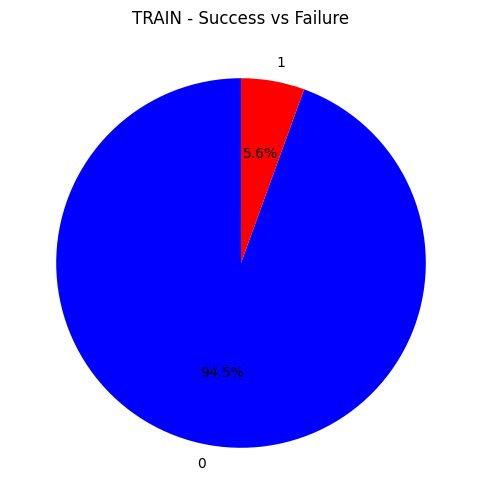

'TEST Value counts'

Target
0    0.9436
1    0.0564
Name: proportion, dtype: float64

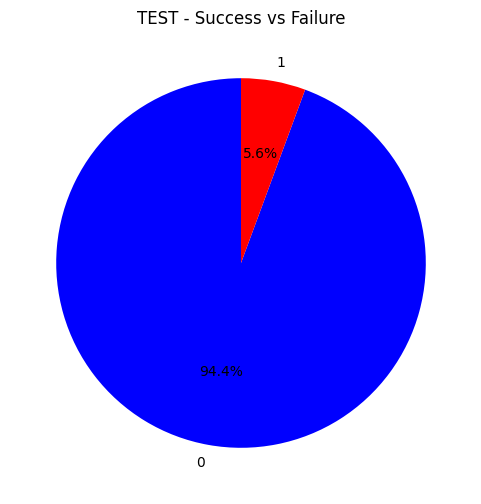

In [7]:
display('TRAIN Value counts', df_train[target].value_counts(True))

target_train_counts = df_train[target].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(target_train_counts, labels=target_train_counts.index, autopct='%1.1f%%', colors=['blue', 'red'], startangle=90)
plt.title('TRAIN - Success vs Failure')
plt.show()

display('TEST Value counts', df_test[target].value_counts(True))

target_test_counts = df_test[target].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(target_test_counts, labels=target_test_counts.index, autopct='%1.1f%%', colors=['blue', 'red'], startangle=90)
plt.title('TEST - Success vs Failure')
plt.show()

#### Pairplot for target hue

In [8]:
#EDA.pairplot_all(data=df_train,features = predictors, hues=[target])

---
#### **Obervation Notes:**
* Pairplot with hues takes forever to load, uncomment to see the outout, we will figure out other ways to understand this data better. 
---

#### Histrogram of the target variable

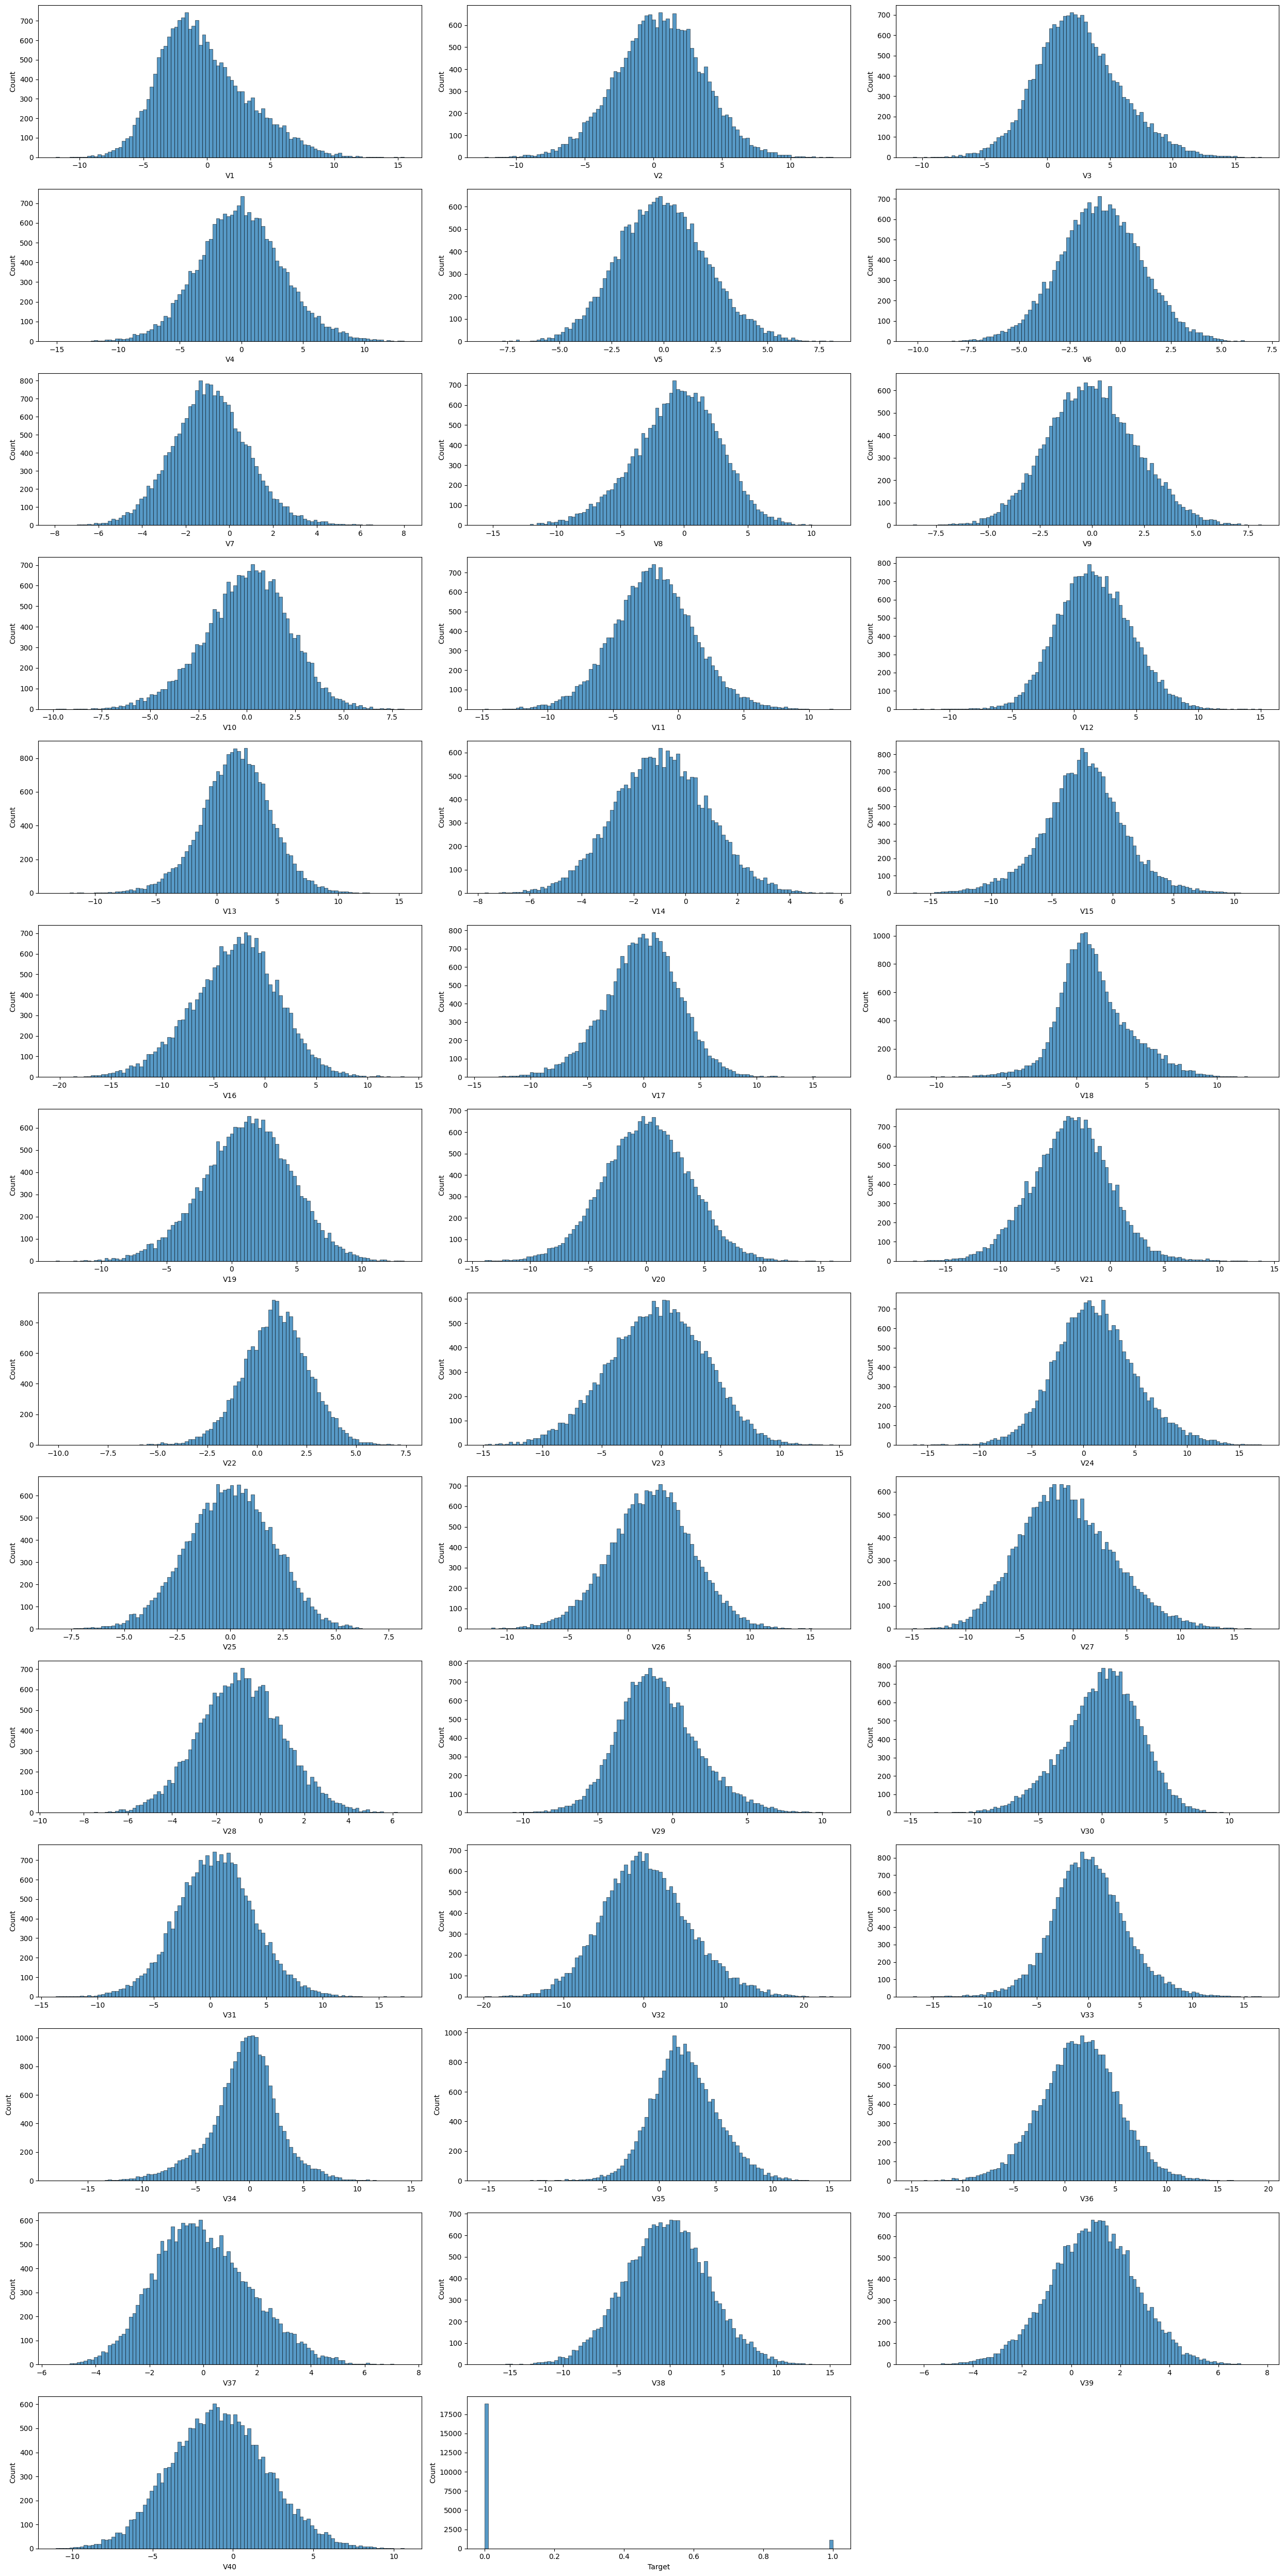

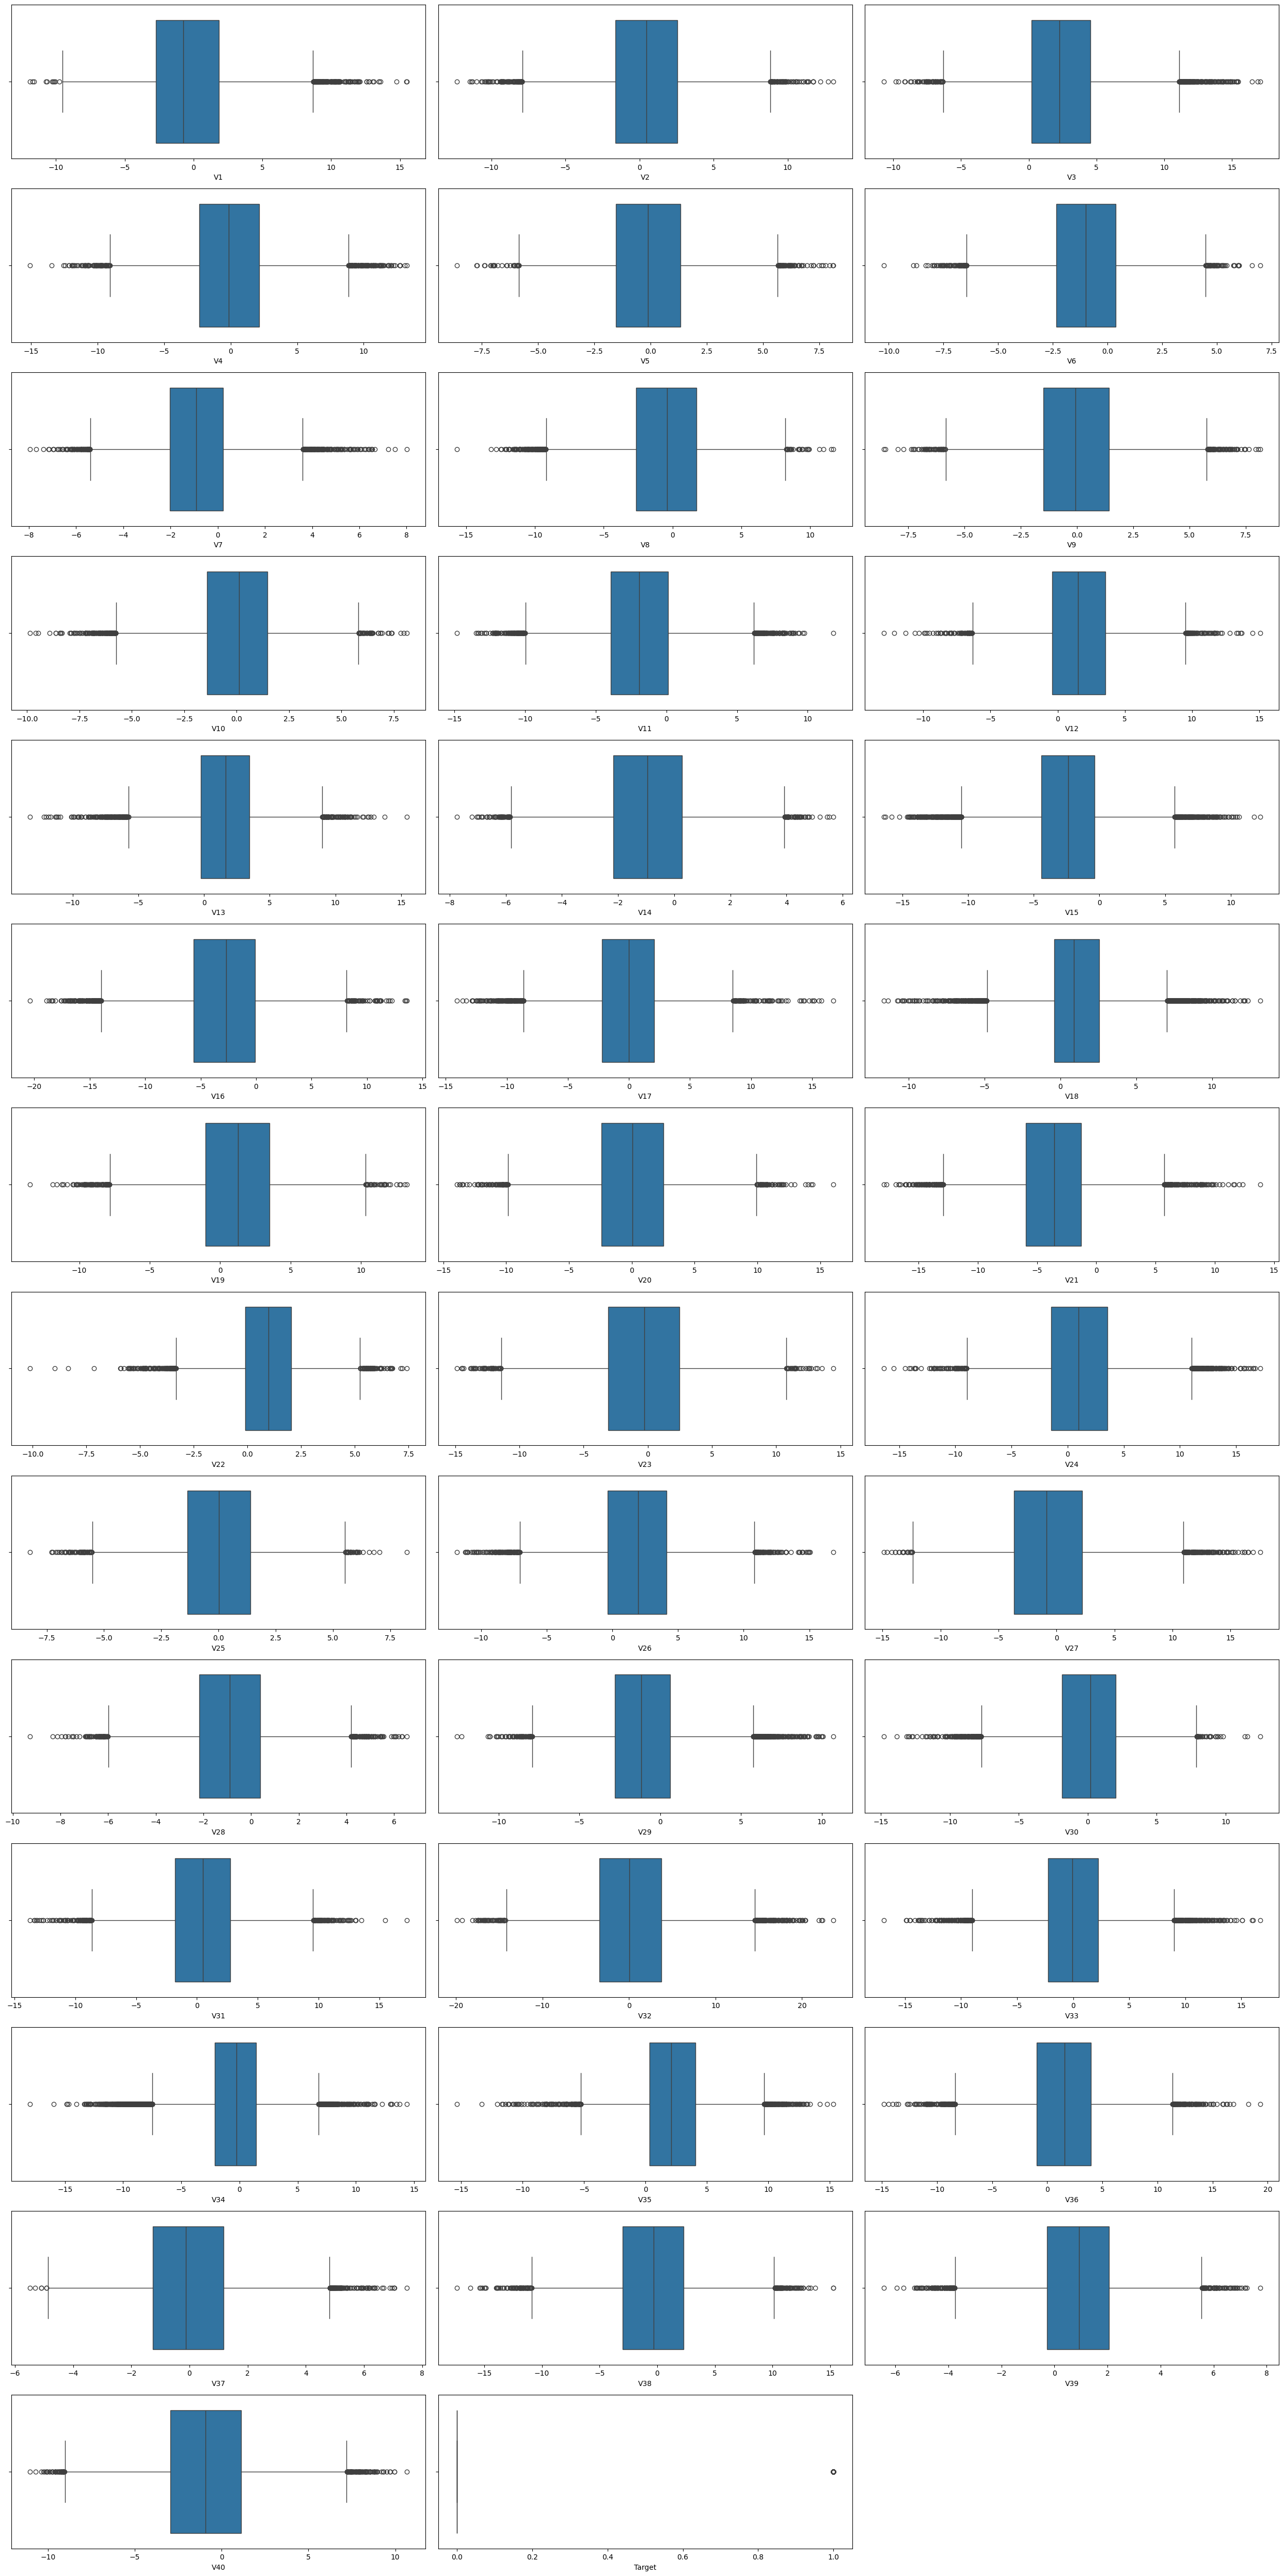

In [9]:
EDA.histogram_boxplot_all(data=df_train, figsize=(25, 50),
                              bins= 100,
                              kde = False)

#### Distribution of target variable

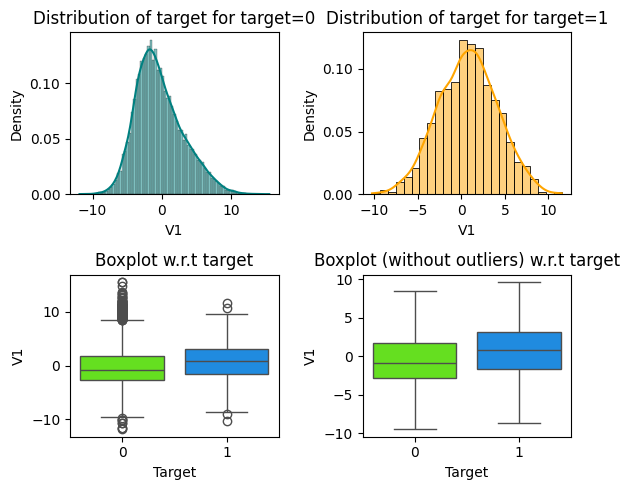

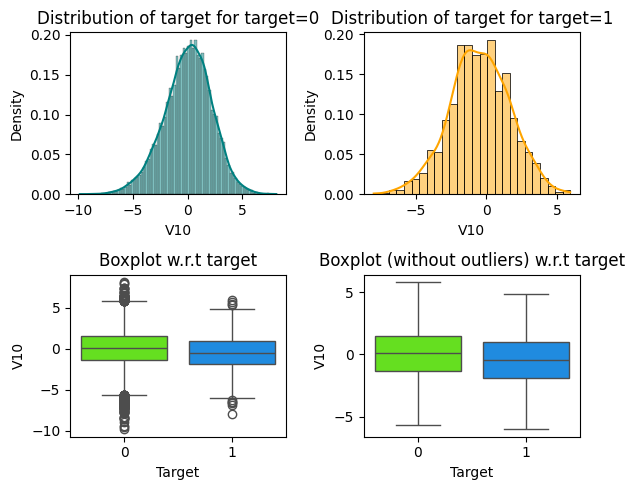

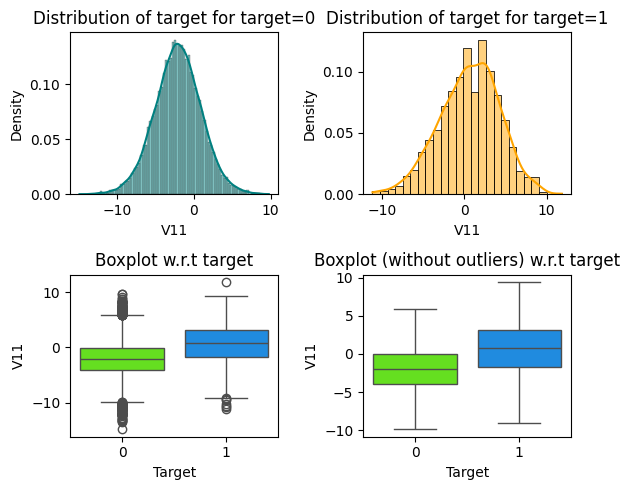

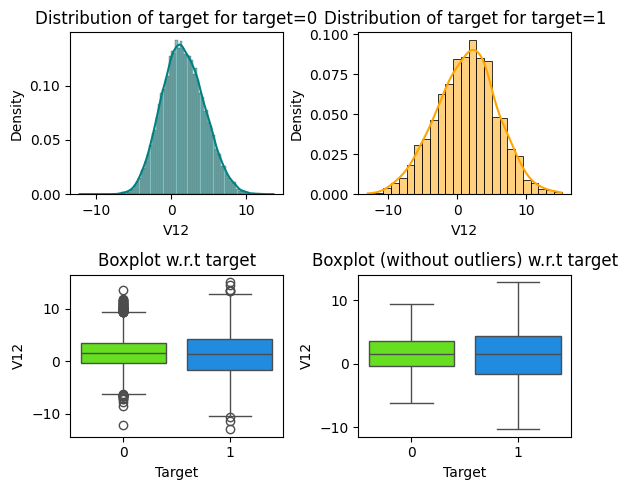

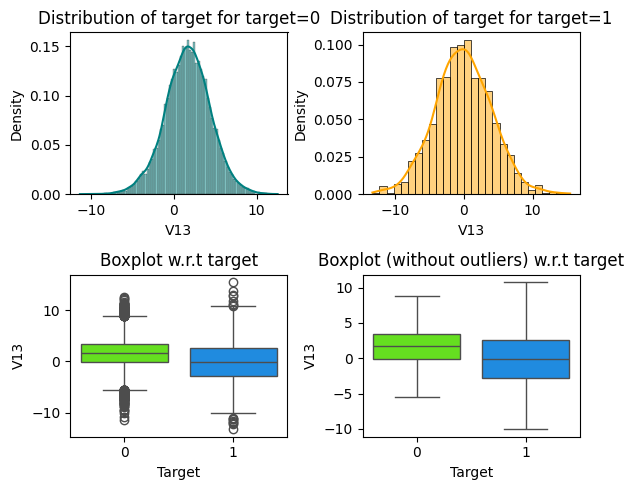

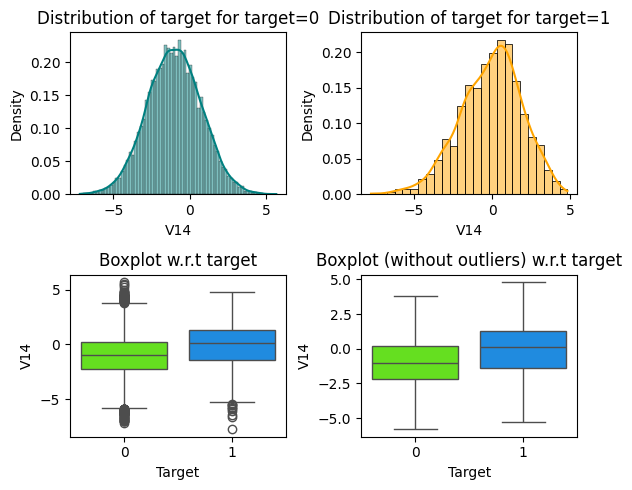

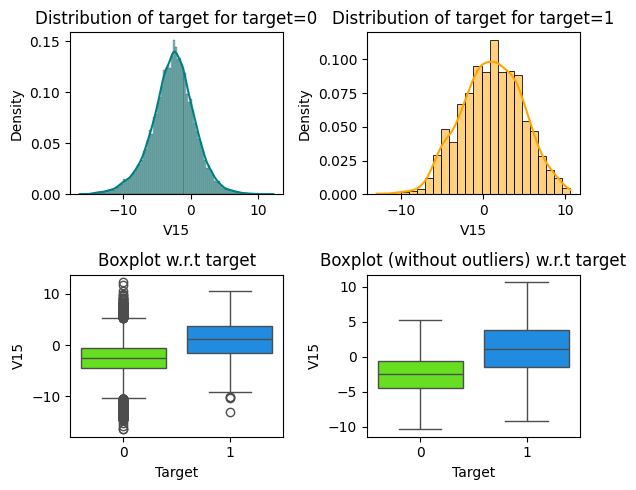

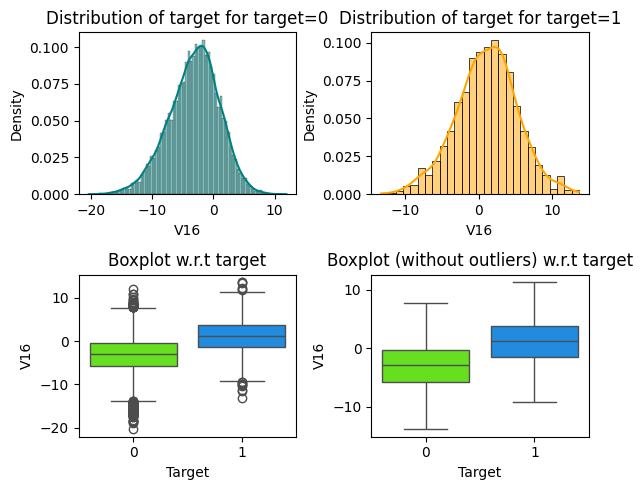

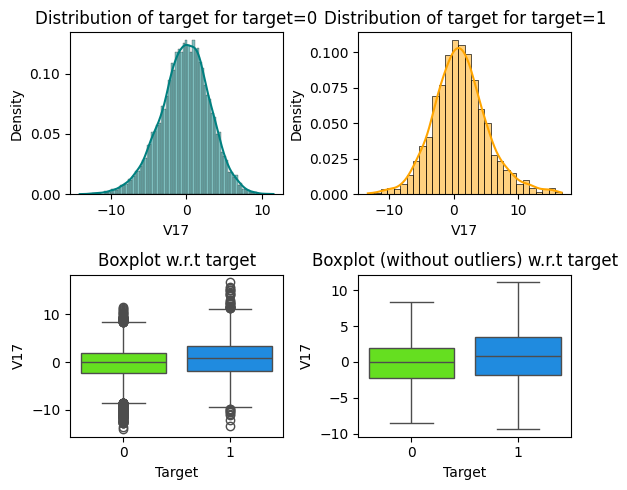

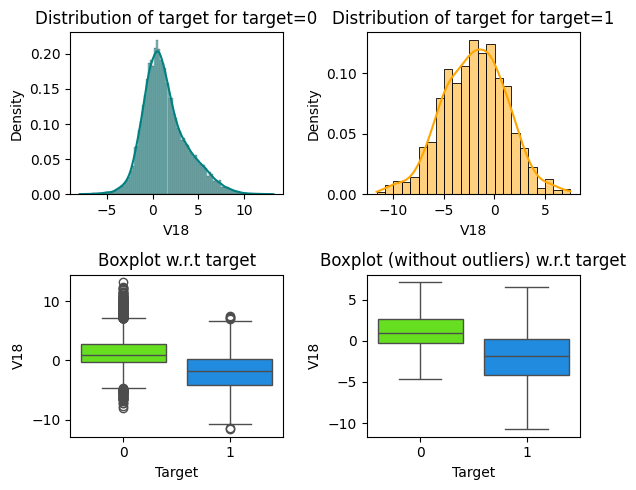

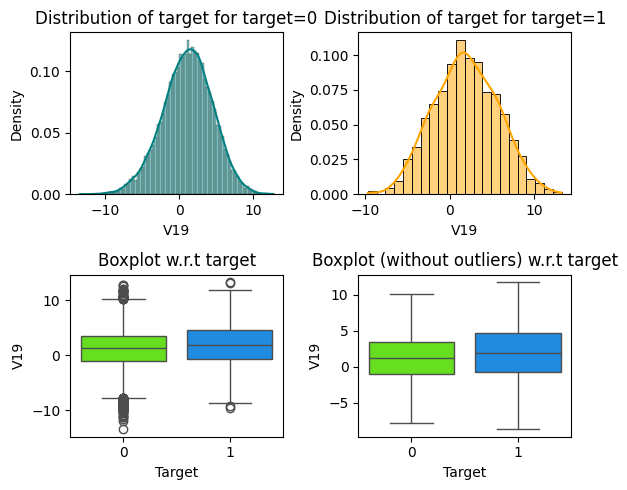

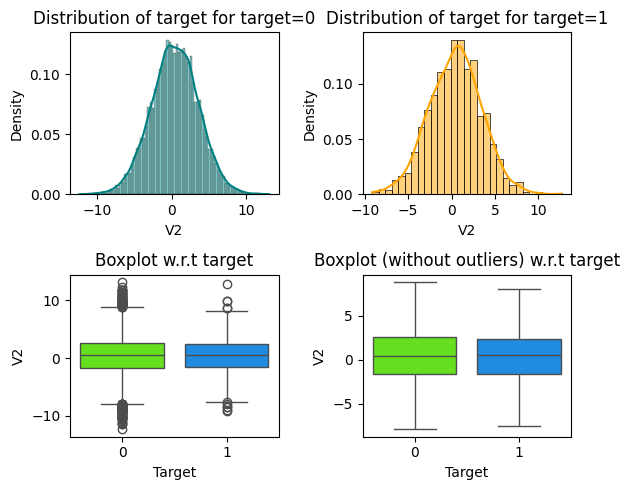

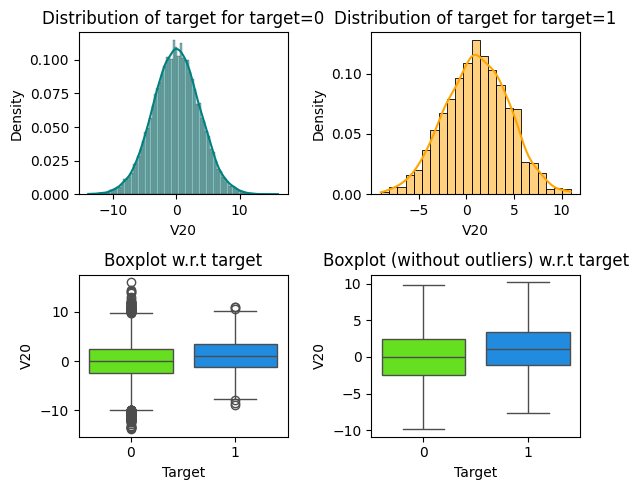

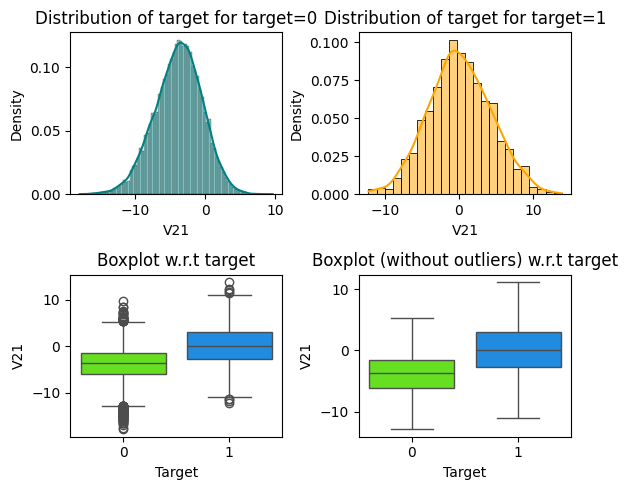

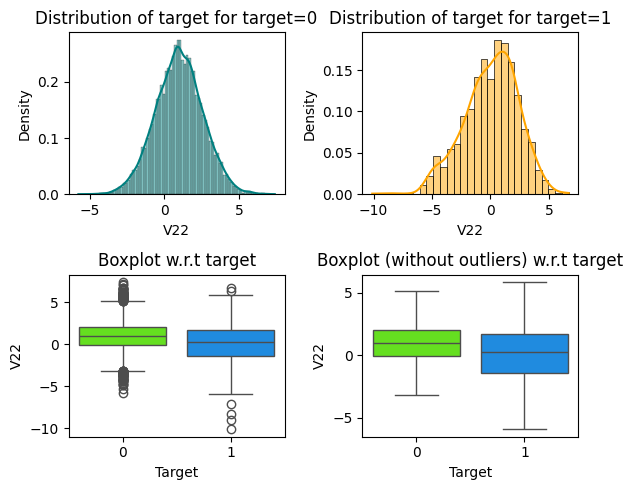

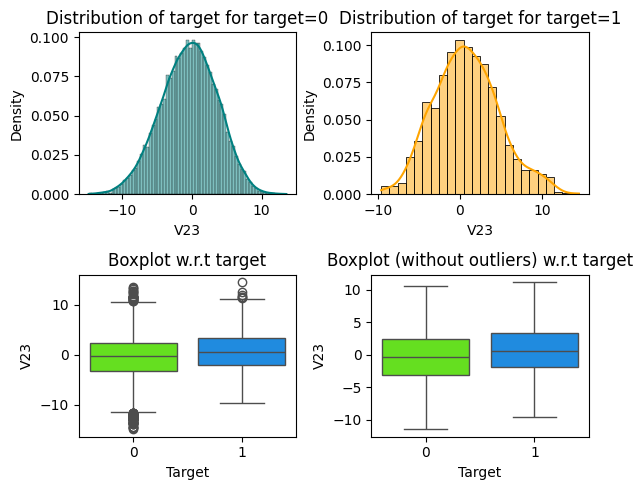

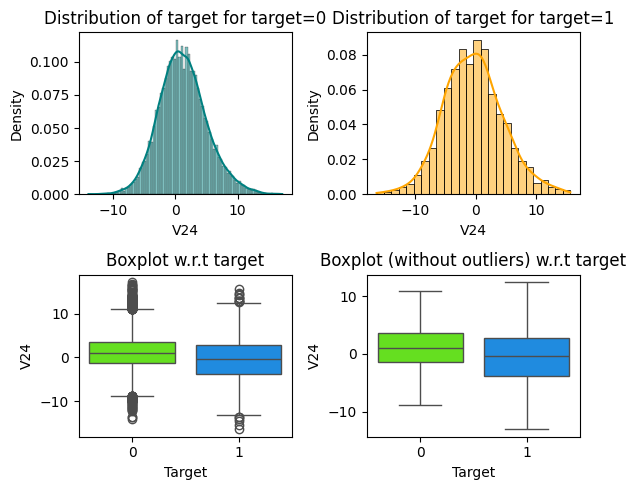

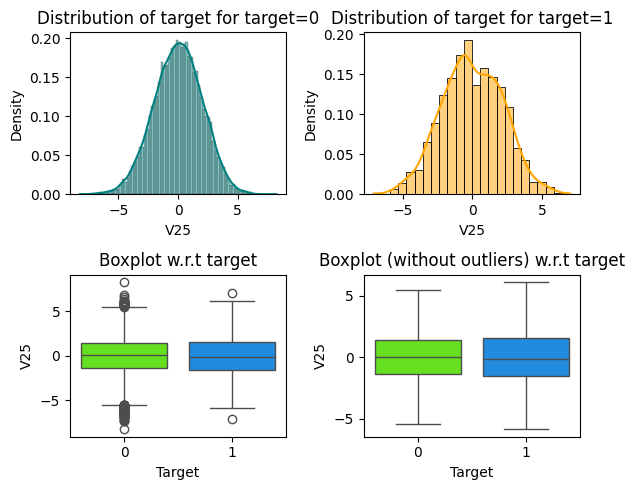

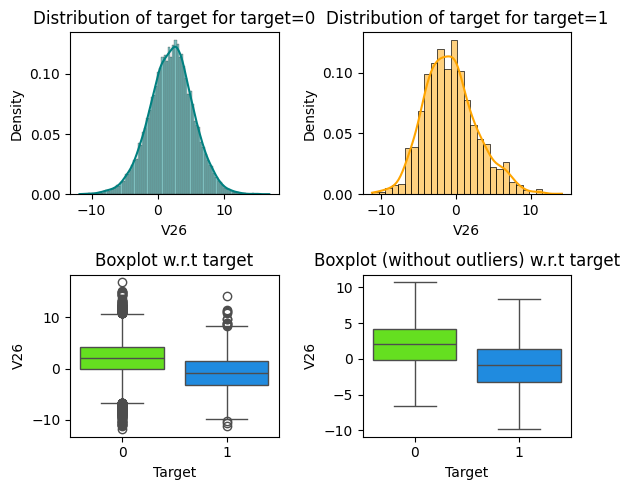

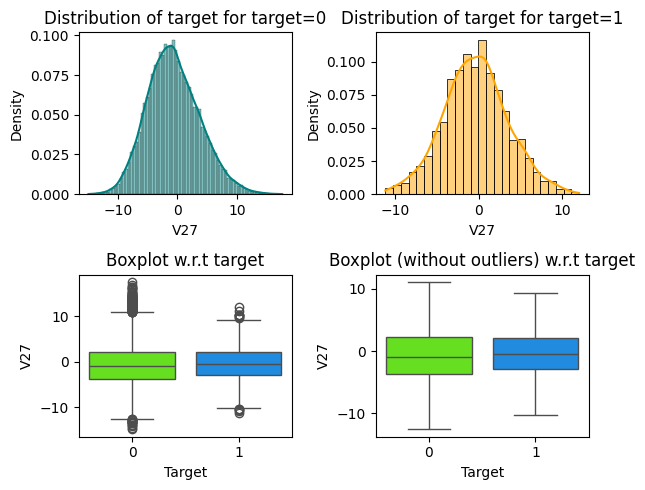

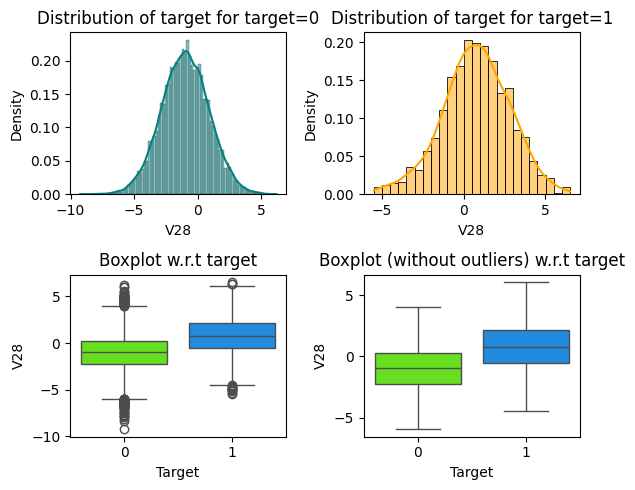

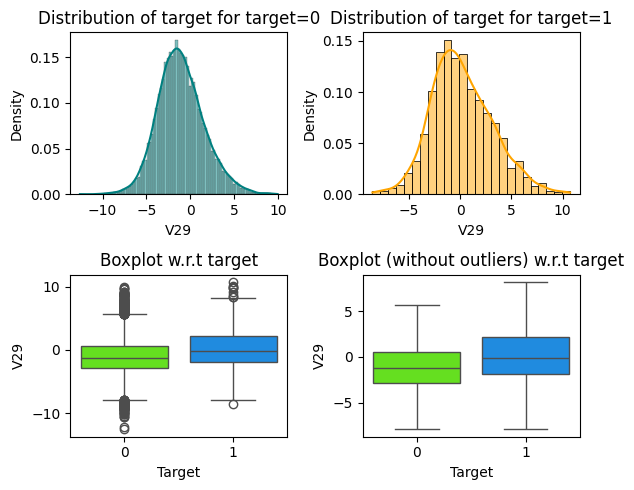

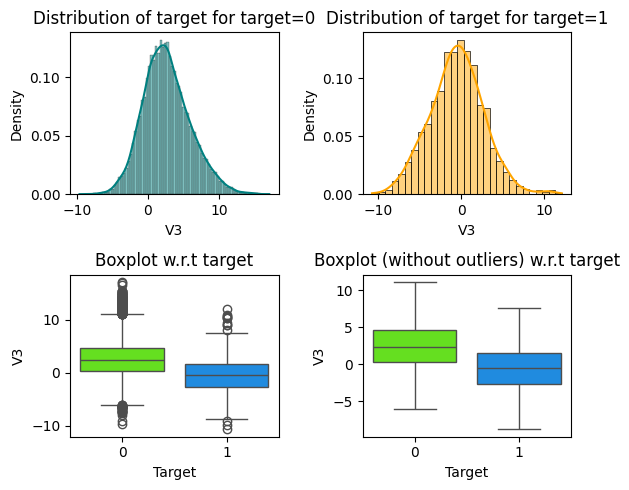

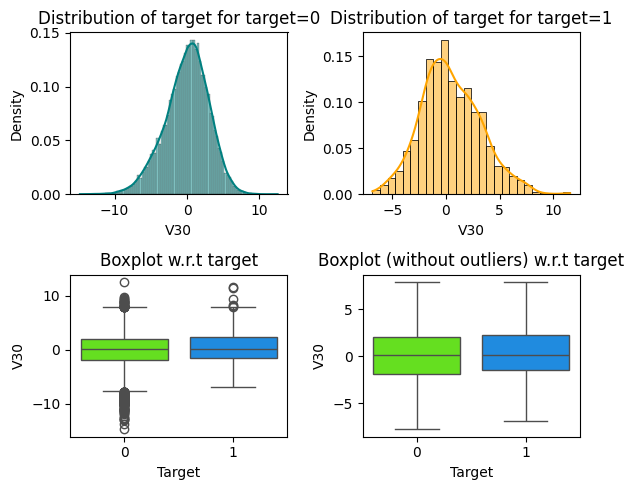

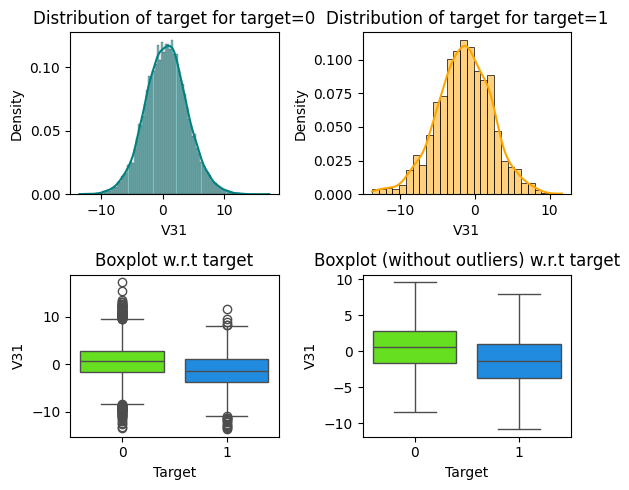

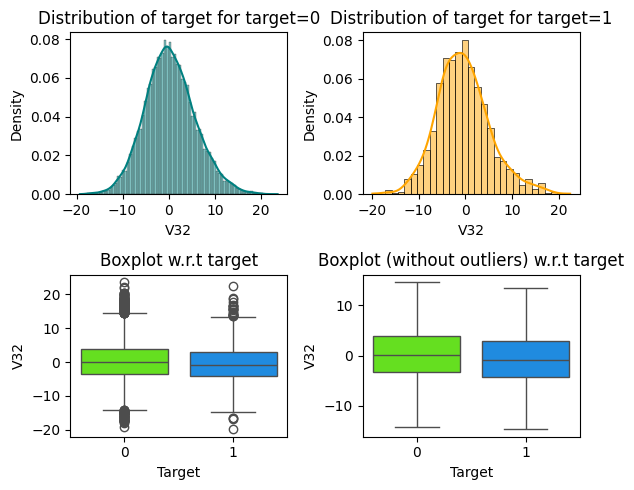

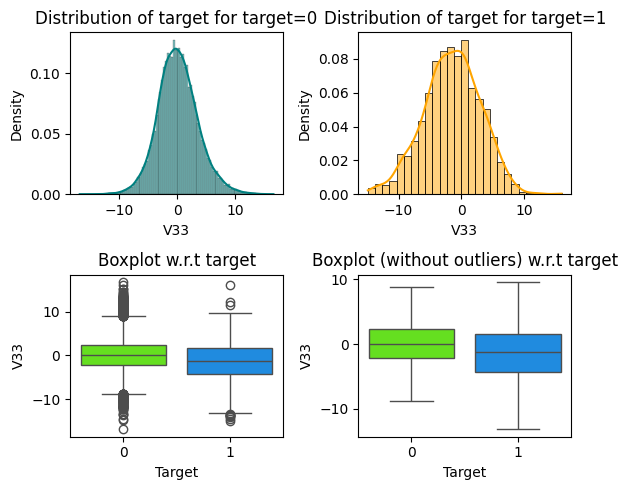

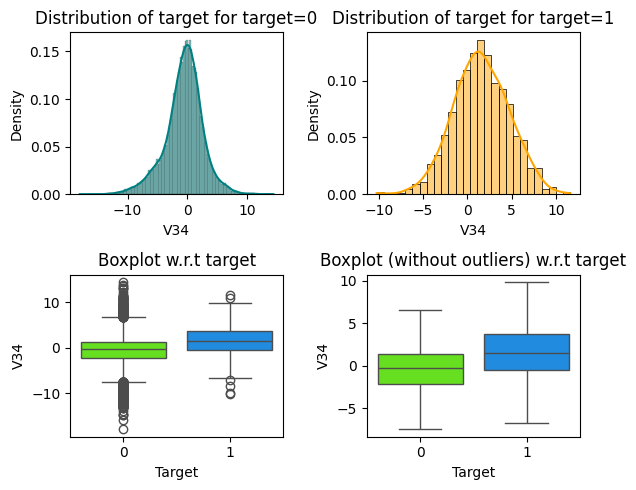

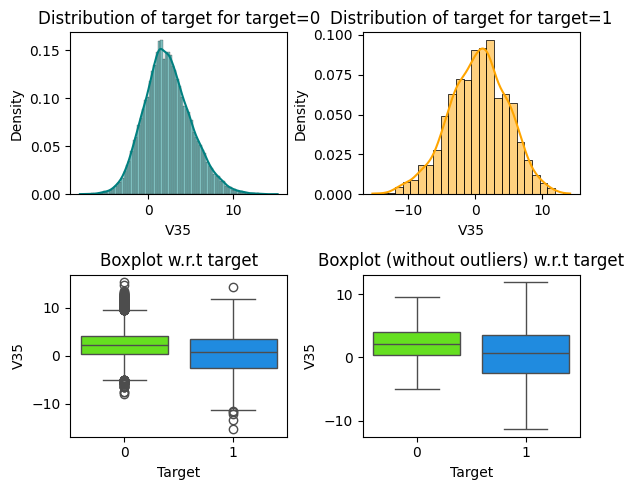

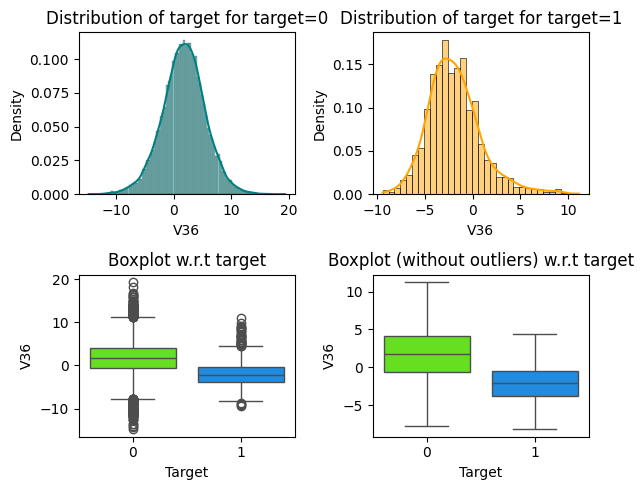

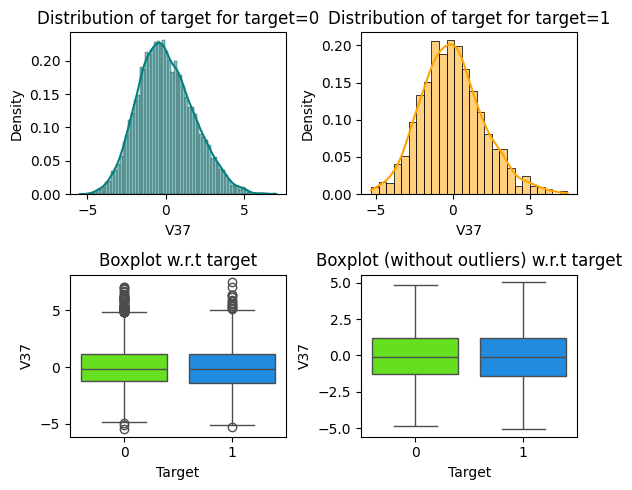

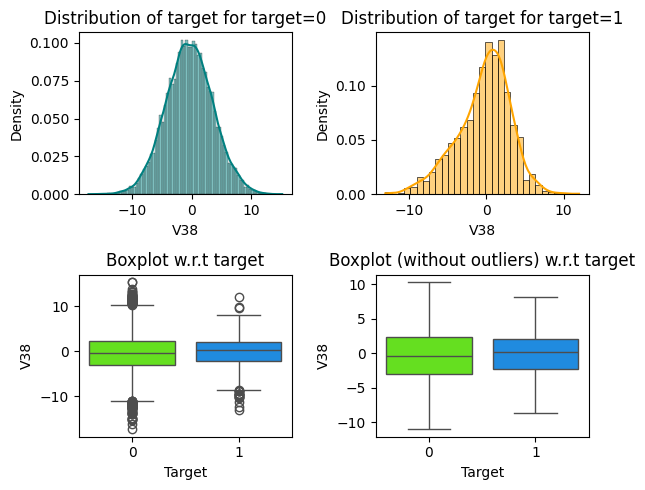

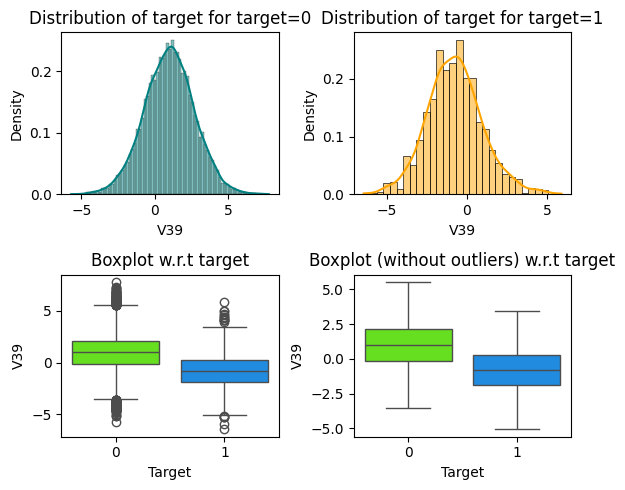

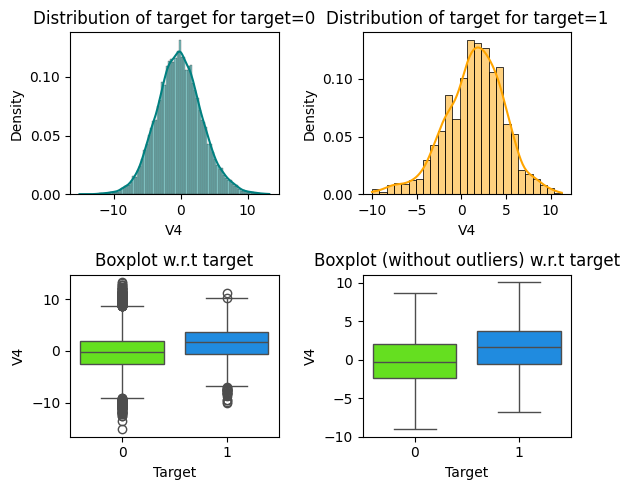

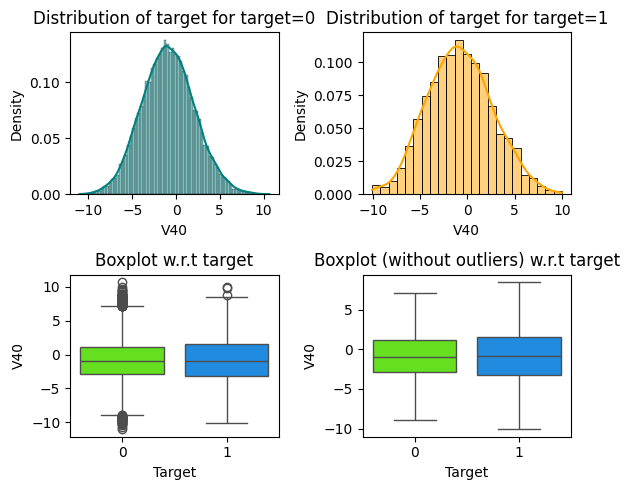

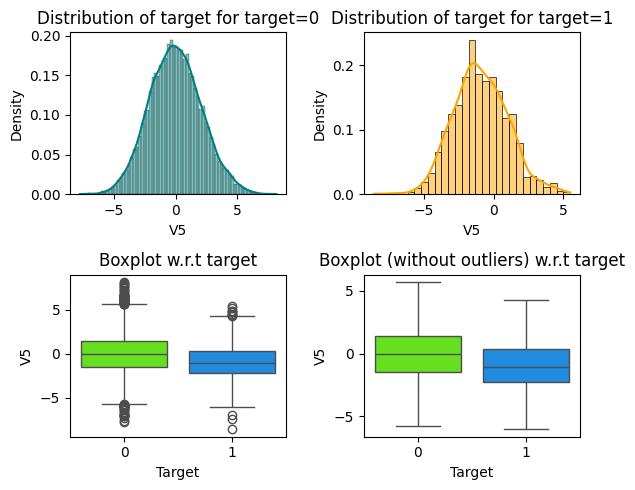

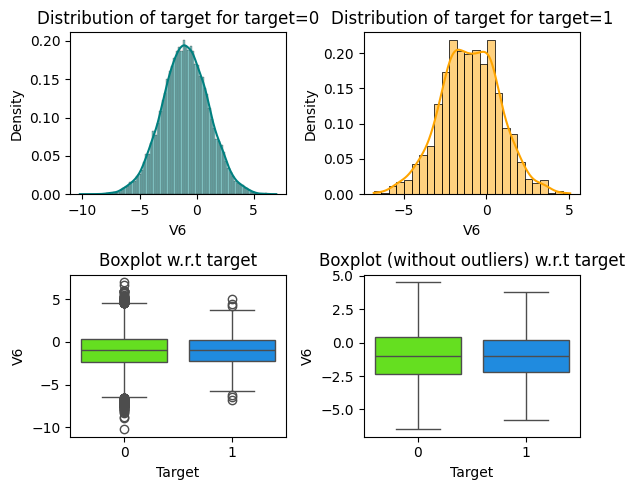

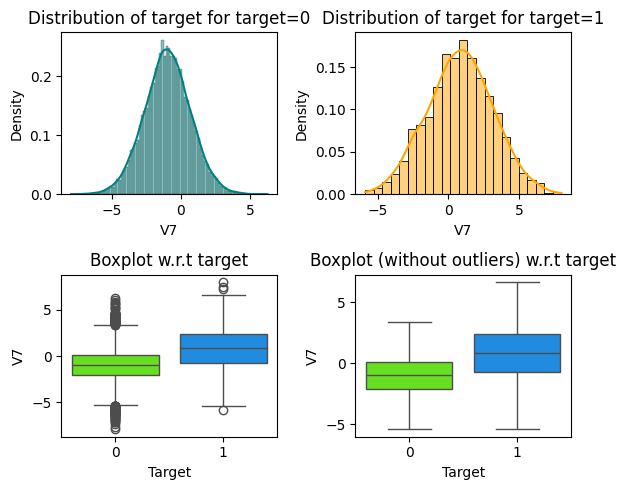

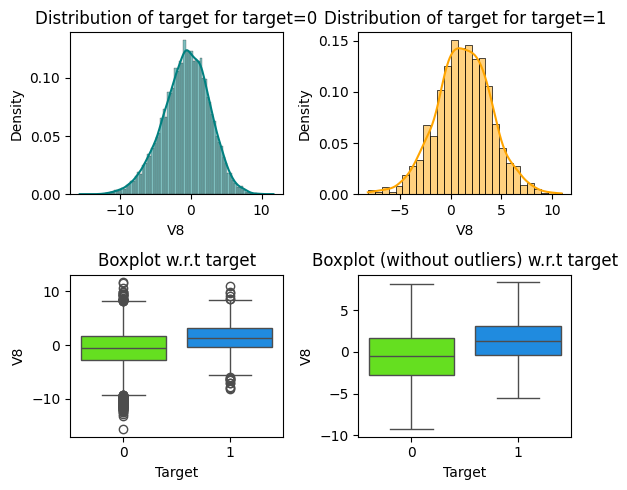

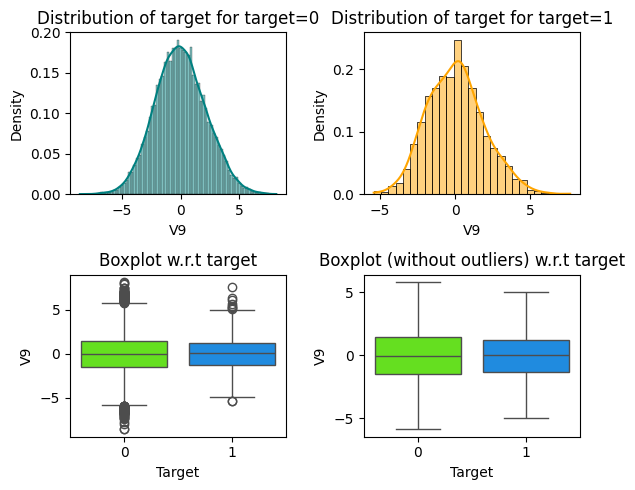

----------------------------------------------------------------------------------------------------


In [10]:
EDA.distribution_plot_for_target_all(data=df_train, predictors=predictors, target=target, figsize=(6,5))

In [11]:
sns.set(font_scale=3)
EDA.heatmap_all(data=df_train, figsize=(100,100))
sns.set(font_scale=1)

---
#### **Observation Notes** : EDA Summary
- We can notice that all independent variables have outliers.
- The target variable is suffering from imbalanced distribution where the (0) is 94% and (1) is 5%.

##### **Impact on 'Target' Variable**

| Feature | Correlation Score | Impact Direction | Description |
| --- | --- | --- | --- |
| V20 | +0.37 | **Strong _Positive_** | The single strongest positive indicator for the Target. |
| V10 | -0.35 | **Strong _Negative_** | The strongest negative driver overall; high values strongly pull the target lower. |
| V30 | +0.34 | **Strong _Positive_** | A major positive influencer for the target classification. |
| V13 | +0.32 | **Strong _Positive_** | Significant positive contributor to the model's decision-making. |
| V2, V9 | -0.31 | **Strong _Negative_** | Both features show identical strong inverse relationships with the Target. |
| V18 | -0.29 | **Moderate _Negative_** | Reliable negative predictor, often moving in opposition to the target. |
| V39 | +0.27 | **Moderate _Positive_** | Notable positive driver identified in the feature set. |

##### **Inter-Feature Dependencies**

Beyond the direct impact on the Target, several feature pairs exhibit high correlations with each other, indicating redundancy.

* **Significant Positive Redundancy:**
    * V36 & V38 (+0.86): The highest _positive_ correlation between two independent features, indicating these are nearly redundant.
    * V11 & V29 (+0.81): Very strong _positive_ relationship; these features provide overlapping information.
    * V2 & V26 (+0.78): Strong _positive_ synchronization.


* **Significant Negative Dependencies:**
    * V1 & V14 (-0.85): Extreme _inverse_ relationship; these features almost always move in opposite directions.
    * V3 & V11 (-0.79): High _inverse_ correlation; when V3 is high, V11 is likely to be low.
    * V16 & V18 (-0.69): Notable _negative_ dependency between two features that both impact the model.

--- 
##### **Summary**
* **Normal Distribution:** Most features (e.g., V4, V5, V12, V20) follow a clear Gaussian (bell-curve) distribution, which is ideal for training neural networks as it ensures stable gradient updates.
* **Target Imbalance:** The final histogram for the Target variable reveals a significant class imbalance, with a much higher frequency of one class (likely "0") compared to the other ("1"). This justifies use of SMOTE (OverSampling) to achieve a balanced Recall in tuned models.
* **Target Sensitivity:** The model is most sensitive to **V20** (Positive) and **V10** (Negative). Changes in these variables will likely result in the largest shifts in model output.
    * **Dimensionality Reduction Potential:** Features like **V36/V38** and **V1/V14** are highly correlated. Removing one from each pair may simplify the model without sacrificing predictive power.
    * **Noise Filtering:** Features such as **V1 (0.00)**, **V6 (0.00)**, and **V38 (0.00)** show zero linear correlation with the Target. These are candidates for exclusion to optimize training efficiency.
    * **Thoughts:** Since the strongest correlation is only **0.37**, the underlying patterns are likely non-linear. This justifies using a deep learning approach (like your **3-layer neural network**) rather than simple linear regression. We will still try those just in case.

---

# **Data Preprocessing**

#### Train Validation split

In [12]:
# Create features and target variable
X = df_train.drop(columns = [target]) # Remove the column named 'Target'
y = df_train[target] # Select the column named 'Target'


# Create features and target variable for test data
X_test = df_test.drop(columns = [target]) # Remove the column named 'Target'
y_test = df_test[target] # Select the column named 'Target'

# Checking the missing values again in train, validation and test data
# display(HTML("<h3>Missing values in train, validation and test data</h3>"))
# display(
#     pd.DataFrame(
#         {
#             "X_train":X_train.isnull().sum()[X_train.isnull().sum() > 0],
#             "X_val":X_val.isnull().sum()[X_val.isnull().sum() > 0],
#             "X_test":X_test.isnull().sum()[X_test.isnull().sum() > 0]
#         }, index=[0],
#     )
# )

# Imputing missing values with median
simple_imputer = SimpleImputer(strategy="median")

# Fit and transform the train data
X_imputed  = pd.DataFrame(simple_imputer.fit_transform(X), columns=X.columns)
X_test = pd.DataFrame(simple_imputer.transform(X_test), columns=X.columns)

# Splitting data into training and validation set:
X_train, X_val, y_train, y_val = train_test_split(
    X_imputed, y, test_size=0.2, random_state=1, stratify=y # Define the test size
)

# y_train = y_train.to_series()
# y_val = y_val.to_series()
# y_test = y_test.to_series()

# Checking the shape of the data
display(HTML("<h3>Shape of the data</h3>"))
display(pd.DataFrame({"X_train":X_train.shape, "X_val":X_val.shape, "X_test":X_test.shape}),index=[0])

# Checking the missing values again in train, validation and test data
display(HTML("<h3>Missing values in train, validation and test data</h3>"))
display(
    pd.DataFrame(
        {
            "X_train_imputed":X_train.isnull().sum()[X_train.isnull().sum() > 0],
            "X_val_imputed":X_val.isnull().sum()[X_val.isnull().sum() > 0],
            "X_test_imputed":X_test.isnull().sum()[X_test.isnull().sum() > 0]
        }, index=[0],
    )
)



,X_train,X_val,X_test
0,16000,4000,5000
1,40,40,40


,X_train_imputed,X_val_imputed,X_test_imputed
0,NaN,NaN,NaN


---
#### **Observation Notes** :
* Training and Validation set has 16000, 4000 records respectively, none missing after imputed
* Test has 5000 records, non missing after imputed.
* Considering the data is simply variables, won't be right to do the duplicate analysis. 
---

### Create Scaled Data

In [13]:
# setting sklean confi
set_config(transform_output="pandas")

# Create a StandardScaler instance
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train))

# Transform the test data using the *same* scaler instance
X_val_scaled = pd.DataFrame(scaler.transform(X_val))

X_test_scaled = pd.DataFrame(scaler.transform(X_test))
# You can now use X_train_scaled and X_test_scaled to train your model
# print('Unscaled')
# print(f"Mean of unscaled training data (feature 1): {X_train.iloc[:,1].mean():.2f}")
# print(f"Std dev of unscaled training data (feature 1): {X_train.iloc[:, 1].std():.2f}")
# print(f"Mean of unscaled test data (feature 1): {X_val.iloc[:,1].mean():.2f}")
# print(f"Std dev of unscaled test data (feature 1): {X_val.iloc[:,1].std():.2f}")


# # You can now use X_train_scaled and X_test_scaled to train your model
# print('Scaled')
# print(f"Mean of scaled training data (feature 0): {X_train_scaled.iloc[:, 1].mean():.2f}")
# print(f"Std dev of scaled training data (feature 0): {X_train_scaled.iloc[:, 1].std():.2f}")
# print(f"Mean of scaled test data (feature 0): {X_val_scaled.iloc[:, 1].mean():.2f}")
# print(f"Std dev of scaled test data (feature 0): {X_val_scaled.iloc[:, 1].std():.2f}")

display("Unscaled X_train", X_train.describe().T)
display("Scaled X_train", X_train_scaled.describe().T)
display("Unscaled X_val", X_val.describe().T)
display("Scaled X_val", X_val_scaled.describe().T)



'Unscaled X_train'

,count,mean,std,min,25%,50%,75%,max
V1,16000.0,-0.279075,3.439376,-11.691484,-2.731485,-0.755843,1.822521,13.594492
V2,16000.0,0.438983,3.161700,-12.319951,-1.645496,0.471536,2.546672,13.089269
V3,16000.0,2.476013,3.375829,-9.810496,0.213979,2.267858,4.544002,17.090919
V4,16000.0,-0.089395,3.418648,-15.082052,-2.344840,-0.138819,2.106241,13.236381
V5,16000.0,-0.048269,2.099501,-8.603361,-1.520068,-0.089730,1.345492,8.133797
V6,16000.0,-0.997083,2.044029,-10.227147,-2.352445,-0.992149,0.376815,6.975847
V7,16000.0,-0.872847,1.757692,-7.949681,-2.018622,-0.900410,0.222644,8.006091
V8,16000.0,-0.539968,3.287755,-15.657561,-2.620631,-0.374883,1.736466,11.679495
V9,16000.0,-0.027176,2.144081,-8.596313,-1.490909,-0.079625,1.386194,8.137580
V10,16000.0,-0.008775,2.193753,-9.596214,-1.402602,0.105493,1.488720,8.108472


'Scaled X_train'

,count,mean,std,min,25%,50%,75%,max
V1,16000.0,2.753353e-17,1.000031,-3.318266,-0.713061,-0.138625,0.611059,4.033871
V2,16000.0,-7.549517e-18,1.000031,-4.035593,-0.659311,0.010296,0.666652,4.001227
V3,16000.0,-1.221245e-17,1.000031,-3.639667,-0.670089,-0.061662,0.612606,4.329414
V4,16000.0,-1.132427e-17,1.000031,-4.385689,-0.659768,-0.014458,0.642273,3.898089
V5,16000.0,8.881784e-18,1.000031,-4.074949,-0.701045,-0.019749,0.663874,3.897270
V6,16000.0,3.996803e-17,1.000031,-4.515764,-0.663104,0.002414,0.672173,3.900717
V7,16000.0,-6.039613e-17,1.000031,-4.026334,-0.651884,-0.015682,0.623275,5.051633
V8,16000.0,-7.549517e-18,1.000031,-4.598294,-0.632872,0.050214,0.692419,3.716775
V9,16000.0,1.820766e-17,1.000031,-3.996773,-0.682707,-0.024463,0.659217,3.808163
V10,16000.0,-1.909584e-17,1.000031,-4.370473,-0.635382,0.052090,0.682639,3.700280


'Unscaled X_val'

,count,mean,std,min,25%,50%,75%,max
V1,4000.0,-0.245823,3.443320,-11.876451,-2.745359,-0.713141,1.893462,15.493002
V2,4000.0,0.446357,3.099923,-10.467607,-1.598649,0.455972,2.524809,11.712574
V3,4000.0,2.519443,3.441207,-10.708139,0.180687,2.202777,4.635230,15.134979
V4,4000.0,-0.058178,3.483223,-13.458282,-2.353948,-0.124835,2.170713,12.095351
V5,4000.0,-0.075683,2.125991,-7.698665,-1.582399,-0.155597,1.309033,7.137820
V6,4000.0,-0.988883,2.028928,-8.303148,-2.328923,-1.022546,0.391100,5.996742
V7,4000.0,-0.905235,1.777262,-6.680786,-2.066423,-0.971746,0.231575,7.520457
V8,4000.0,-0.581104,3.327777,-11.856411,-2.698691,-0.434891,1.685181,9.805001
V9,4000.0,0.024665,2.225085,-7.977675,-1.506391,-0.028261,1.534976,7.942547
V10,4000.0,-0.029888,2.191185,-9.853957,-1.453984,0.087010,1.413538,7.195514


'Scaled X_val'

,count,mean,std,min,25%,50%,75%,max
V1,4000.0,0.009668,1.001178,-3.372047,-0.717096,-0.126209,0.631686,4.585881
V2,4000.0,0.002332,0.980491,-3.449704,-0.644494,0.005373,0.659737,3.565785
V3,4000.0,0.012865,1.019398,-3.905578,-0.679951,-0.080942,0.639631,3.750001
V4,4000.0,0.009132,1.018921,-3.910700,-0.662432,-0.010367,0.661132,3.564312
V5,4000.0,-0.013058,1.012649,-3.644026,-0.730735,-0.051122,0.646508,3.422868
V6,4000.0,0.004012,0.992643,-3.574457,-0.651596,-0.012458,0.679162,3.421695
V7,4000.0,-0.018427,1.011165,-3.304401,-0.679080,-0.056268,0.628356,4.775334
V8,4000.0,-0.012512,1.012205,-3.442105,-0.656615,0.031961,0.676820,3.146613
V9,4000.0,0.024179,1.037813,-3.708231,-0.689928,-0.000506,0.728611,3.717197
V10,4000.0,-0.009624,0.998861,-4.487966,-0.658804,0.043664,0.648368,3.284105


#### Compare side-by-side (only shows differences)

In [14]:

# Compare side-by-side (only shows differences)
pd.set_option('display.max_rows', 500)
display("Comparison of unscaled and scaled X_train", (X_train.describe().compare(X_train_scaled.describe())).T)
display("Comparison of unscaled and scaled X_val", (X_val.describe().compare(X_val_scaled.describe())).T)

'Comparison of unscaled and scaled X_train'

mean       std        min       25%       50%       75%  \
V1  self  -2.790750e-01  3.439376 -11.691484 -2.731485 -0.755843  1.822521   
    other  2.753353e-17  1.000031  -3.318266 -0.713061 -0.138625  0.611059   
V2  self   4.389832e-01  3.161700 -12.319951 -1.645496  0.471536  2.546672   
    other -7.549517e-18  1.000031  -4.035593 -0.659311  0.010296  0.666652   
V3  self   2.476013e+00  3.375829  -9.810496  0.213979  2.267858  4.544002   
    other -1.221245e-17  1.000031  -3.639667 -0.670089 -0.061662  0.612606   
V4  self  -8.939522e-02  3.418648 -15.082052 -2.344840 -0.138819  2.106241   
    other -1.132427e-17  1.000031  -4.385689 -0.659768 -0.014458  0.642273   
V5  self  -4.826874e-02  2.099501  -8.603361 -1.520068 -0.089730  1.345492   
    other  8.881784e-18  1.000031  -4.074949 -0.701045 -0.019749  0.663874   
V6  self  -9.970829e-01  2.044029 -10.227147 -2.352445 -0.992149  0.376815   
    other  3.996803e-17  1.000031  -4.515764 -0.663104  0.002414  0.672173   
V7  self  -8.728470e-01  1.757692  -7.949681 -2.018622 -0.900410  0.222644   
    other -6.039613e-17  1.000031  -4.026334 -0.651884 -0.015682  0.623275   
V8  self  -5.399683e-01  3.287755 -15.657561 -2.620631 -0.374883  1.736466   
    other -7.549517e-18  1.000031  -4.598294 -0.632872  0.050214  0.692419   
V9  self  -2.717569e-02  2.144081  -8.596313 -1.490909 -0.079625  1.386194   
    other  1.820766e-17  1.000031  -3.996773 -0.682707 -0.024463  0.659217   
V10 self  -8.775471e-03  2.193753  -9.596214 -1.402602  0.105493  1.488720   
    other -1.909584e-17  1.000031  -4.370473 -0.635382  0.052090  0.682639   
V11 self  -1.900067e+00  3.125646 -14.832058 -3.920645 -1.913877  0.113373   
    other -1.776357e-17  1.000031  -4.137511 -0.646472 -0.004418  0.644188   
V12 self   1.619952e+00  2.929885 -12.948007 -0.377587  1.524945  3.571559   
    other  4.218847e-17  1.000031  -4.972351 -0.681802 -0.032428  0.666124   
V13 self   1.573774e+00  2.853382 -13.228247 -0.228532  1.617884  3.460339   
    other  9.237056e-17  1.000031  -5.187697 -0.631658  0.015459  0.661189   
V14 self  -9.475920e-01  1.796810  -7.738593 -2.175168 -0.955576  0.277235   
    other  5.151435e-17  1.000031  -3.779595 -0.683219 -0.004444  0.681689   
V15 self  -2.405938e+00  3.340808 -16.416606 -4.386357 -2.356652 -0.352125   
    other  5.595524e-17  1.000031  -4.193927 -0.592815  0.014753  0.614785   
V16 self  -2.912429e+00  4.200314 -20.374158 -5.623064 -2.652139 -0.099087   
    other -3.019807e-17  1.000031  -4.157373 -0.645361  0.061971  0.669814   
V17 self  -1.292678e-01  3.322008 -14.091184 -2.213607 -0.014312  2.066986   
    other  1.887379e-18  1.000031  -4.202986 -0.627453  0.034605  0.661143   
V18 self   1.192258e+00  2.579350 -11.643994 -0.398140  0.885441  2.559279   
    other -4.618528e-17  1.000031  -4.976701 -0.616608 -0.118955  0.530003   
V19 self   1.181175e+00  3.396502 -13.491784 -1.050616  1.279361  3.498995   
    other -7.205347e-17  1.000031  -4.320156 -0.657106  0.028909  0.682435   
V20 self   2.100757e-02  3.658498 -13.729438 -2.435275  0.015895  2.495404   
    other  7.327472e-18  1.000031  -3.758612 -0.671412 -0.001397  0.676363   
V21 self  -3.597461e+00  3.552671 -17.730295 -5.909351 -3.515603 -1.263371   
    other -5.018208e-17  1.000031  -3.978211 -0.650767  0.023042  0.657016   
V22 self   9.535281e-01  1.646350 -10.122095 -0.124877  0.970565  2.022579   
    other -5.595524e-17  1.000031  -6.727590 -0.655048  0.010348  0.649367   
V23 self  -3.528013e-01  4.027048 -14.866128 -3.073837 -0.253997  2.446633   
    other  1.110223e-17  1.000031  -3.604074 -0.675711  0.024536  0.695180   
V24 self   1.143602e+00  3.891049 -16.387147 -1.449575  0.978924  3.550563   
    other  8.881784e-18  1.000031  -4.505545 -0.666468 -0.042324  0.618609   
V25 self  -2.575418e-03  2.011503  -7.292048 -1.363213  0.016002  1.395996   
    other -7.105427e-18  1.000031  -3.624007 -0.676450  0.009236  0.695309   
V26 self   1.866943e+00  3.439683 -11.834

'Comparison of unscaled and scaled X_val'

mean       std        min       25%       50%       75%  \
V1  self  -0.245823  3.443320 -11.876451 -2.745359 -0.713141  1.893462   
    other  0.009668  1.001178  -3.372047 -0.717096 -0.126209  0.631686   
V2  self   0.446357  3.099923 -10.467607 -1.598649  0.455972  2.524809   
    other  0.002332  0.980491  -3.449704 -0.644494  0.005373  0.659737   
V3  self   2.519443  3.441207 -10.708139  0.180687  2.202777  4.635230   
    other  0.012865  1.019398  -3.905578 -0.679951 -0.080942  0.639631   
V4  self  -0.058178  3.483223 -13.458282 -2.353948 -0.124835  2.170713   
    other  0.009132  1.018921  -3.910700 -0.662432 -0.010367  0.661132   
V5  self  -0.075683  2.125991  -7.698665 -1.582399 -0.155597  1.309033   
    other -0.013058  1.012649  -3.644026 -0.730735 -0.051122  0.646508   
V6  self  -0.988883  2.028928  -8.303148 -2.328923 -1.022546  0.391100   
    other  0.004012  0.992643  -3.574457 -0.651596 -0.012458  0.679162   
V7  self  -0.905235  1.777262  -6.680786 -2.066423 -0.971746  0.231575   
    other -0.018427  1.011165  -3.304401 -0.679080 -0.056268  0.628356   
V8  self  -0.581104  3.327777 -11.856411 -2.698691 -0.434891  1.685181   
    other -0.012512  1.012205  -3.442105 -0.656615  0.031961  0.676820   
V9  self   0.024665  2.225085  -7.977675 -1.506391 -0.028261  1.534976   
    other  0.024179  1.037813  -3.708231 -0.689928 -0.000506  0.728611   
V10 self  -0.029888  2.191185  -9.853957 -1.453984  0.087010  1.413538   
    other -0.009624  0.998861  -4.487966 -0.658804  0.043664  0.648368   
V11 self  -1.876699  3.119341 -12.179995 -3.925030 -1.952086  0.147459   
    other  0.007476  0.998014  -3.289000 -0.647874 -0.016643  0.655093   
V12 self   1.544317  2.932318 -12.168157 -0.447394  1.431186  3.571133   
    other -0.025816  1.000862  -4.706172 -0.705629 -0.064430  0.665979   
V13 self   1.607333  2.958444 -11.256857 -0.206354  1.682056  3.457122   
    other  0.011761  1.036852  -4.496780 -0.623885  0.037950  0.660061   
V14 self  -0.962794  1.760897  -6.557434 -2.152686 -0.961554  0.241938   
    other -0.008461  0.980044  -3.122210 -0.670707 -0.007771  0.662044   
V15 self  -2.451213  3.411231 -14.522677 -4.510909 -2.443377 -0.408667   
    other -0.013553  1.021111  -3.627002 -0.630098 -0.011207  0.597859   
V16 self  -2.976406  4.306418 -18.362013 -5.682185 -2.802955 -0.089001   
    other -0.015232  1.025293  -3.678312 -0.659437  0.026064  0.672216   
V17 self  -0.154236  3.438030 -13.626454 -2.233136 -0.018387  2.069831   
    other -0.007516  1.034958  -4.063087 -0.633332  0.033379  0.661999   
V18 self   1.177702  2.643646 -10.341646 -0.438767  0.878529  2.627864   
    other -0.005644  1.024959  -4.471772 -0.632359 -0.121635  0.556594   
V19 self   1.184339  3.399042 -10.209537 -1.041866  1.267503  3.475809   
    other  0.000931  1.000779  -3.353765 -0.654529  0.025418  0.675608   
V20 self   0.034007  3.713510 -13.922659 -2.410665  0.108923  2.559143   
    other  0.003553  1.015068  -3.811428 -0.664685  0.024031  0.693786   
V21 self  -3.666414  3.627068 -17.956231 -6.021788 -3.614464 -1.276323   
    other -0.019410  1.020973  -4.041809 -0.682417 -0.004786  0.653370   
V22 self   0.945064  1.672361  -8.344792 -0.104141  0.999512  2.045270   
    other -0.005141  1.015831  -5.648015 -0.642452  0.027932  0.663150   
V23 self  -0.419376  4.051120 -12.893428 -3.235172 -0.294883  2.469500   
    other -0.016532  1.006009  -3.114196 -0.715775  0.014383  0.700858   
V24 self   1.097537  3.995323 -14.463112 -1.522656  0.928191  3.513912   
    other -0.011839  1.026831  -4.011052 -0.685250 -0.055362  0.609189   
V25 self  -0.000629  2.037805  -8.228266 -1.368146  0.079585  1.399781   
    other  0.000968  1.013108  -4.089453 -0.678902  0.040847  0.697190   
V26 self   1.901152  3.417182 -11.076329 -0.325841  1.975946  4.157847   
    other  0.009946  0.993490  -3.763043 -0.637516  0.031691  0.666043   
V27 self  -0.619745  4.432656 -13.198644 -3.691259 -0.933855  2.042335   
    other -0.002106

# **Model Building**

## Model Building

### Regression Models - Linear and Logistic Regression both. 

,Accuracy,Recall,Precision,F1
0,0.36,0.954955,0.076756,0.142091


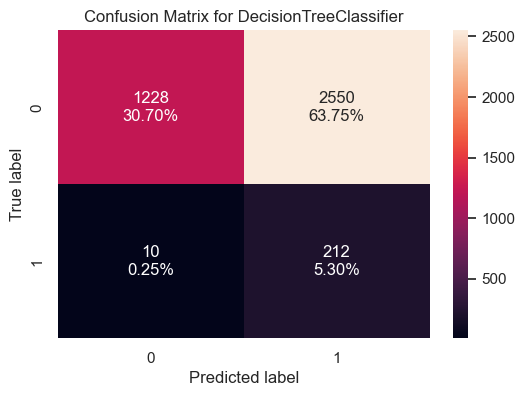

,Accuracy,Recall,Precision,F1
0,0.36,0.954955,0.076756,0.142091


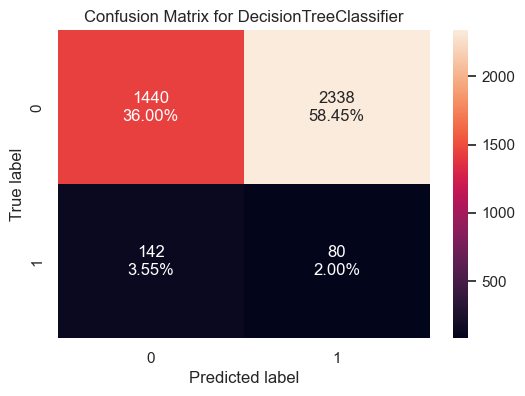

,Accuracy,Recall,Precision,F1
0,0.96675,0.490991,0.844961,0.621083


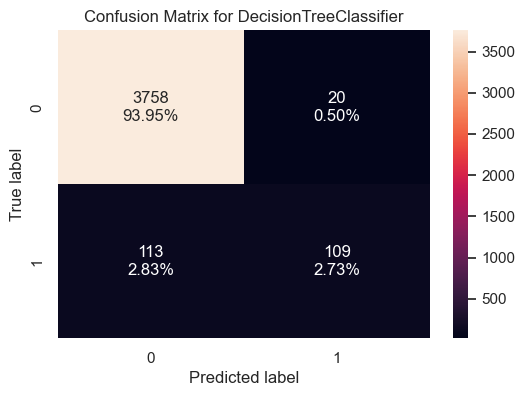

,Accuracy,Recall,Precision,F1
0,0.96675,0.490991,0.844961,0.621083


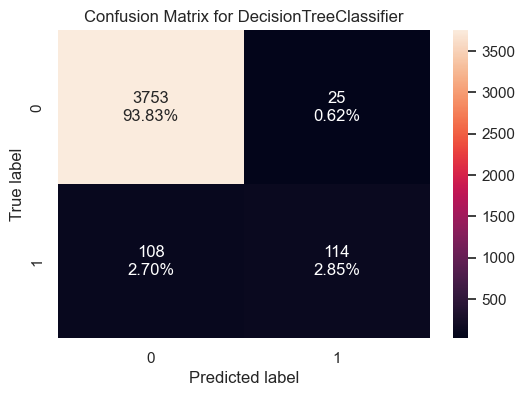

In [15]:
# Linear Regression Unscaled
model = LinearRegression()
model.fit(X_train,y_train)
model_performance =  MLM.model_performance_classification(model=model,predictors=X_val,expected=y_val,printall=True, title="LinearRegression - Unscaled")
MLM.plot_confusion_matrix(model=model,predictors=X_val,expected=y_val,convert_pred_to_binary=True)

# Linear Regression Scaled
model = LinearRegression()
model.fit(X_train_scaled, y_train)
model_performance = MLM.model_performance_classification(model=model,predictors=X_val_scaled,expected=y_val,printall=True, title="LinearRegression - Scaled")
MLM.plot_confusion_matrix(model=model,predictors=X_val,expected=y_val,convert_pred_to_binary=True)


# Logistic Regression Unscaled
model = LogisticRegression(solver='lbfgs', random_state=VKPy.RANDOM_STATE)
model.fit(X_train, y_train)
model_performance = MLM.model_performance_classification(model=model,predictors=X_val,expected=y_val,printall=True, title="LogisticRegression - Unscaled")
MLM.plot_confusion_matrix(model=model,predictors=X_val,expected=y_val,convert_pred_to_binary=True)

# Logistic Regression Scaled
model = LogisticRegression(solver='lbfgs', random_state=VKPy.RANDOM_STATE)
model.fit(X_train_scaled, y_train)
model_performance = MLM.model_performance_classification(model=model,predictors=X_val_scaled,expected=y_val,printall=True, title="LogisticRegression - Scaled")
MLM.plot_confusion_matrix(model=model,predictors=X_val,expected=y_val,convert_pred_to_binary=True)

---
#### **Observation Notes** :
- Focus of this project is mainly on the Neural Networks, so hereafter focusing on those. 
- Regression models may get better results if tried to Over / Under sampling 
- Feature importance would be easier to understand if we use boosting or bagging techniques, which will also get better recall rate. 
- Leaving the Boosting, Bagging, Over and Undersampling for another day, and focus on Neural Networks. After project, will try to add those techniques to complete the project in true sense. 
---

### Machine Learning Models

#### Display Functions

In [20]:
"""
# Build a function to show the graph of each model
"""
def showgraph(df_results, title):
    df_melted = df_results.melt(id_vars=['ModelName', 'Run'], 
                        value_vars=['Accuracy', 'Recall', 'Precision', 'F1'],
                        var_name='Metric', value_name='Score')
    
    # Set visual style
    metrics = ['Accuracy', 'Recall', 'Precision', 'F1']
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    sns.set_style("whitegrid")
    
    for i, metric in enumerate(metrics):
        # Assign the plot to a variable 'ax' to access its containers
        ax = sns.barplot(data=df_melted[df_melted['Metric'] == metric],
                        x='ModelName', y='Score', hue='Run', ax=axes[i], palette='viridis')
        
        # --- ADD VALUE LABELS HERE ---
        # Iterate through the bar containers (one for each 'Run')
        for container in ax.containers:
            ax.bar_label(container, fmt='%.3f', padding=3, fontsize=8, rotation=90)
          
        # -----------------------------
        
        axes[i].set_title(f'Model Comparison: {metric}', fontsize=8)
        axes[i].set_ylim(0, 1.2) # Increased limit slightly to fit labels on top
        axes[i].set_ylabel('Score')
        axes[i].set_xlabel('Model Name')
        axes[i].legend(title='Run', loc='lower right')
        axes[i].tick_params(axis='x', rotation=90)

   
    plt.tight_layout()
    plt.savefig(f'{title}.png')
    plt.show()

#### Base Models

In [16]:
ml_models = []
ml_model_results = pd.DataFrame(columns=["Type","ModelName","Run", "Accuracy", "Recall", "Precision", "F1"])


ml_models.append(("BaggingClassifier",  BaggingClassifier(estimator=DecisionTreeClassifier(random_state=VKPy.RANDOM_STATE,class_weight='balanced'),random_state=VKPy.RANDOM_STATE)))
ml_models.append(('RandomForestClassifier', RandomForestClassifier(random_state=VKPy.RANDOM_STATE,class_weight='balanced')))
ml_models.append(('GradientBoost',  GradientBoostingClassifier(random_state=VKPy.RANDOM_STATE)))
ml_models.append(('AdaBoostClassifier', AdaBoostClassifier(random_state=VKPy.RANDOM_STATE)))
ml_models.append(('DecisionTreeClassifier', DecisionTreeClassifier(random_state=VKPy.RANDOM_STATE)))
ml_models.append(('XGBClassifier', XGBClassifier(random_state= VKPy.RANDOM_STATE,eval_metric="logloss")))

for model_name, model_in in ml_models:
  
    model_in.fit(X_train,y_train)

    perf_results = MLM.model_performance_classification(model=model_in,predictors=X_train, expected=y_train, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
    perf_results["Type"] = "Original" 
    perf_results["ModelName"] = model_name 
    perf_results["Run"] = "Training"
    ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)

 
    perf_results = MLM.model_performance_classification(model=model_in,predictors=X_val, expected=y_val, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
    perf_results["Type"] = "Original" 
    perf_results["ModelName"] = model_name 
    perf_results["Run"] = "Validation"
    ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)

    perf_results = MLM.model_performance_classification(model=model_in,predictors=X_test, expected=y_test, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
    perf_results["Type"] = "Original" 
    perf_results["ModelName"] = model_name 
    perf_results["Run"] = "Testing"
    ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)
    
display(ml_model_results)

,Type,ModelName,Run,Accuracy,Recall,Precision,F1
0,Original,BaggingClassifier,Training,0.9975,0.956081,0.998824,0.976985
1,Original,BaggingClassifier,Validation,0.9795,0.671171,0.943038,0.784211
2,Original,BaggingClassifier,Testing,0.9778,0.631206,0.962162,0.762313
3,Original,RandomForestClassifier,Training,1.0,1.0,1.0,1.0
4,Original,RandomForestClassifier,Validation,0.98175,0.684685,0.980645,0.806366
5,Original,RandomForestClassifier,Testing,0.9824,0.698582,0.985,0.817427
6,Original,GradientBoost,Training,0.989187,0.814189,0.989056,0.893144
7,Original,GradientBoost,Validation,0.9815,0.743243,0.906593,0.816832
8,Original,GradientBoost,Testing,0.977,0.680851,0.884793,0.769539
9,Original,AdaBoostClassifier,Training,0.96925,0.54955,0.841379,0.66485


#### Create Oversampled and Undersampled data

In [17]:
display("Before Sampling", y_train.value_counts())

sm = SMOTE(sampling_strategy=1,k_neighbors=5,random_state=VKPy.RANDOM_STATE)
X_train_over, y_train_over = sm.fit_resample(X_train,y_train)
display("After oversampling", y_train_over.value_counts())

rus = RandomUnderSampler(random_state=EDA.RANDOM_STATE)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)
display("After undersample", y_train_under.value_counts())

'Before Sampling'

Target
0    15112
1      888
Name: count, dtype: int64

'After oversampling'

Target
0    15112
1    15112
Name: count, dtype: int64

'After undersample'

Target
0    888
1    888
Name: count, dtype: int64

#### Over and Undersampling

In [18]:
ml_models_over = []

ml_models_over.append(("BaggingClassifier",  BaggingClassifier(estimator=DecisionTreeClassifier(random_state=VKPy.RANDOM_STATE,class_weight='balanced'),random_state=VKPy.RANDOM_STATE)))
ml_models_over.append(('RandomForestClassifier', RandomForestClassifier(random_state=VKPy.RANDOM_STATE,class_weight='balanced')))
ml_models_over.append(('GradientBoost',  GradientBoostingClassifier(random_state=VKPy.RANDOM_STATE)))
ml_models_over.append(('AdaBoostClassifier', AdaBoostClassifier(random_state=VKPy.RANDOM_STATE)))
ml_models_over.append(('DecisionTreeClassifier', DecisionTreeClassifier(random_state=VKPy.RANDOM_STATE)))
ml_models_over.append(('XGBClassifier', XGBClassifier(random_state= VKPy.RANDOM_STATE,eval_metric="logloss")))

for model_name, model_in in ml_models_over:
  
    model_in.fit(X_train_over,y_train_over)

    perf_results = MLM.model_performance_classification(model=model_in,predictors=X_train_over, expected=y_train_over, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
    perf_results["Type"] = "OverSampled" 
    perf_results["ModelName"] = model_name 
    perf_results["Run"] = "Training"
    ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)

 
    perf_results = MLM.model_performance_classification(model=model_in,predictors=X_val, expected=y_val, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
    perf_results["Type"] = "OverSampled" 
    perf_results["ModelName"] = model_name 
    perf_results["Run"] = "Validation"
    ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)

    perf_results = MLM.model_performance_classification(model=model_in,predictors=X_test, expected=y_test, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
    perf_results["Type"] = "OverSampled" 
    perf_results["ModelName"] = model_name 
    perf_results["Run"] = "Testing"
    ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)
    
display(ml_model_results)

,Type,ModelName,Run,Accuracy,Recall,Precision,F1
0,Original,BaggingClassifier,Training,0.9975,0.956081,0.998824,0.976985
1,Original,BaggingClassifier,Validation,0.9795,0.671171,0.943038,0.784211
2,Original,BaggingClassifier,Testing,0.9778,0.631206,0.962162,0.762313
3,Original,RandomForestClassifier,Training,1.0,1.0,1.0,1.0
4,Original,RandomForestClassifier,Validation,0.98175,0.684685,0.980645,0.806366
5,Original,RandomForestClassifier,Testing,0.9824,0.698582,0.985,0.817427
6,Original,GradientBoost,Training,0.989187,0.814189,0.989056,0.893144
7,Original,GradientBoost,Validation,0.9815,0.743243,0.906593,0.816832
8,Original,GradientBoost,Testing,0.977,0.680851,0.884793,0.769539
9,Original,AdaBoostClassifier,Training,0.96925,0.54955,0.841379,0.66485


In [ ]:
def run_ml_models(models_in : list, 
                  hyperparameter_tuning : bool = False,
                  X_train : pd.DataFrame,
                  y_train : pd.DataFrame,
                  X_train_over : pd.DataFrame = None,
                  y_train_over : pd.DataFrame = None,
                  X_train_under : pd.DataFrame = None,
                  y_train_under : pd.DataFrame = None,
                  X_val : pd.DataFrame,
                  y_val : pd.DataFrame,
                  X_test : pd.DataFrame,
                  y_test : pd.DataFrame,
                  ml_model_results : pd.DataFrame,
                  THRESHOLD : float,
                  scorer = metrics.make_scorer(metrics.recall_score)
                  ):

    models_original = []
    models_tuned = []
    models_over = []
    models_under = []


    # Type of scoring used to compare parameter combinations
    acc_scorer = metrics.make_scorer(metrics.f1_score)

    model_original = copy.deepcopy(models_in)
    
    if X_train_over is not None:
        models_over = copy.deepcopy(models_in)
    
    if X_train_under is not None:
        models_under = copy.deepcopy(models_in)
    
    if hyperparameter_tuning:
        models_tuned = copy.deepcopy(models_in)
        for model_name, model_in, param_grid in models_tuned:
            
            
    
    for model_name, model_in in model_original:
    
        model_in.fit(X_train,y_train)

        perf_results = MLM.model_performance_classification(model=model_in,predictors=X_train, expected=y_train, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
        perf_results["Type"] = "Original" 
        perf_results["ModelName"] = model_name 
        perf_results["Run"] = "Training"
        ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)

    
        perf_results = MLM.model_performance_classification(model=model_in,predictors=X_val, expected=y_val, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
        perf_results["Type"] = "Original" 
        perf_results["ModelName"] = model_name 
        perf_results["Run"] = "Validation"
        ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)

        perf_results = MLM.model_performance_classification(model=model_in,predictors=X_test, expected=y_test, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
        perf_results["Type"] = "Original" 
        perf_results["ModelName"] = model_name 
        perf_results["Run"] = "Testing"
        ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)
    
    for model_name, model_in in models_over:
    
        model_in.fit(X_train_over,y_train_over)

        perf_results = MLM.model_performance_classification(model=model_in,predictors=X_train_over, expected=y_train_over, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
        perf_results["Type"] = "Over" 
        perf_results["ModelName"] = model_name 
        perf_results["Run"] = "Training"
        ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)

    
        perf_results = MLM.model_performance_classification(model=model_in,predictors=X_val, expected=y_val, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
        perf_results["Type"] = "Over" 
        perf_results["ModelName"] = model_name 
        perf_results["Run"] = "Validation"
        ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)

        perf_results = MLM.model_performance_classification(model=model_in,predictors=X_test, expected=y_test, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
        perf_results["Type"] = "Over" 
        perf_results["ModelName"] = model_name 
        perf_results["Run"] = "Testing"
        ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)

    for model_name, model_in in models_under:
    
        model_in.fit(X_train_under,y_train_under)

        perf_results = MLM.model_performance_classification(model=model_in,predictors=X_train_under, expected=y_train_under, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
        perf_results["Type"] = "Under" 
        perf_results["ModelName"] = model_name 
        perf_results["Run"] = "Training"
        ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)

    
        perf_results = MLM.model_performance_classification(model=model_in,predictors=X_val, expected=y_val, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
        perf_results["Type"] = "Under" 
        perf_results["ModelName"] = model_name 
        perf_results["Run"] = "Validation"
        ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)

        perf_results = MLM.model_performance_classification(model=model_in,predictors=X_test, expected=y_test, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
        perf_results["Type"] = "Under" 
        perf_results["ModelName"] = model_name 
        perf_results["Run"] = "Testing"
        ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)

    for model_name, model_in in models_tuned:
    
        model_in.fit(X_train,y_train)

        perf_results = MLM.model_performance_classification(model=model_in,predictors=X_train, expected=y_train, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
        perf_results["Type"] = "Tuned" 
        perf_results["ModelName"] = model_name 
        perf_results["Run"] = "Training"
        ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)

    
        perf_results = MLM.model_performance_classification(model=model_in,predictors=X_val, expected=y_val, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
        perf_results["Type"] = "Tuned" 
        perf_results["ModelName"] = model_name 
        perf_results["Run"] = "Validation"
        ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)

        perf_results = MLM.model_performance_classification(model=model_in,predictors=X_test, expected=y_test, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
        perf_results["Type"] = "Tuned" 
        perf_results["ModelName"] = model_name 
        perf_results["Run"] = "Testing"
        ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)

    return ml_model_results


In [19]:
ml_models_under = []

ml_models_under.append(("BaggingClassifier",  BaggingClassifier(estimator=DecisionTreeClassifier(random_state=VKPy.RANDOM_STATE,class_weight='balanced'),random_state=VKPy.RANDOM_STATE)))
ml_models_under.append(('RandomForestClassifier', RandomForestClassifier(random_state=VKPy.RANDOM_STATE,class_weight='balanced')))
ml_models_under.append(('GradientBoost',  GradientBoostingClassifier(random_state=VKPy.RANDOM_STATE)))
ml_models_under.append(('AdaBoostClassifier', AdaBoostClassifier(random_state=VKPy.RANDOM_STATE)))
ml_models_under.append(('DecisionTreeClassifier', DecisionTreeClassifier(random_state=VKPy.RANDOM_STATE)))
ml_models_under.append(('XGBClassifier', XGBClassifier(random_state= VKPy.RANDOM_STATE,eval_metric="logloss")))

for model_name, model_in in ml_models_under:
  
    model_in.fit(X_train_under,y_train_under)

    perf_results = MLM.model_performance_classification(model=model_in,predictors=X_train_over, expected=y_train_over, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
    perf_results["Type"] = "UnderSampled" 
    perf_results["ModelName"] = model_name 
    perf_results["Run"] = "Training"
    ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)

 
    perf_results = MLM.model_performance_classification(model=model_in,predictors=X_val, expected=y_val, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
    perf_results["Type"] = "UnderSampled" 
    perf_results["ModelName"] = model_name 
    perf_results["Run"] = "Validation"
    ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)

    perf_results = MLM.model_performance_classification(model=model_in,predictors=X_test, expected=y_test, threshold=THRESHOLD,score_average='binary',printall=False,title=model_name)
    perf_results["Type"] = "UnderSampled" 
    perf_results["ModelName"] = model_name 
    perf_results["Run"] = "Testing"
    ml_model_results = pd.concat([ml_model_results, perf_results], ignore_index=True)
    
display(ml_model_results)

,Type,ModelName,Run,Accuracy,Recall,Precision,F1
0,Original,BaggingClassifier,Training,0.9975,0.956081,0.998824,0.976985
1,Original,BaggingClassifier,Validation,0.9795,0.671171,0.943038,0.784211
2,Original,BaggingClassifier,Testing,0.9778,0.631206,0.962162,0.762313
3,Original,RandomForestClassifier,Training,1.0,1.0,1.0,1.0
4,Original,RandomForestClassifier,Validation,0.98175,0.684685,0.980645,0.806366
5,Original,RandomForestClassifier,Testing,0.9824,0.698582,0.985,0.817427
6,Original,GradientBoost,Training,0.989187,0.814189,0.989056,0.893144
7,Original,GradientBoost,Validation,0.9815,0.743243,0.906593,0.816832
8,Original,GradientBoost,Testing,0.977,0.680851,0.884793,0.769539
9,Original,AdaBoostClassifier,Training,0.96925,0.54955,0.841379,0.66485


#### Check results

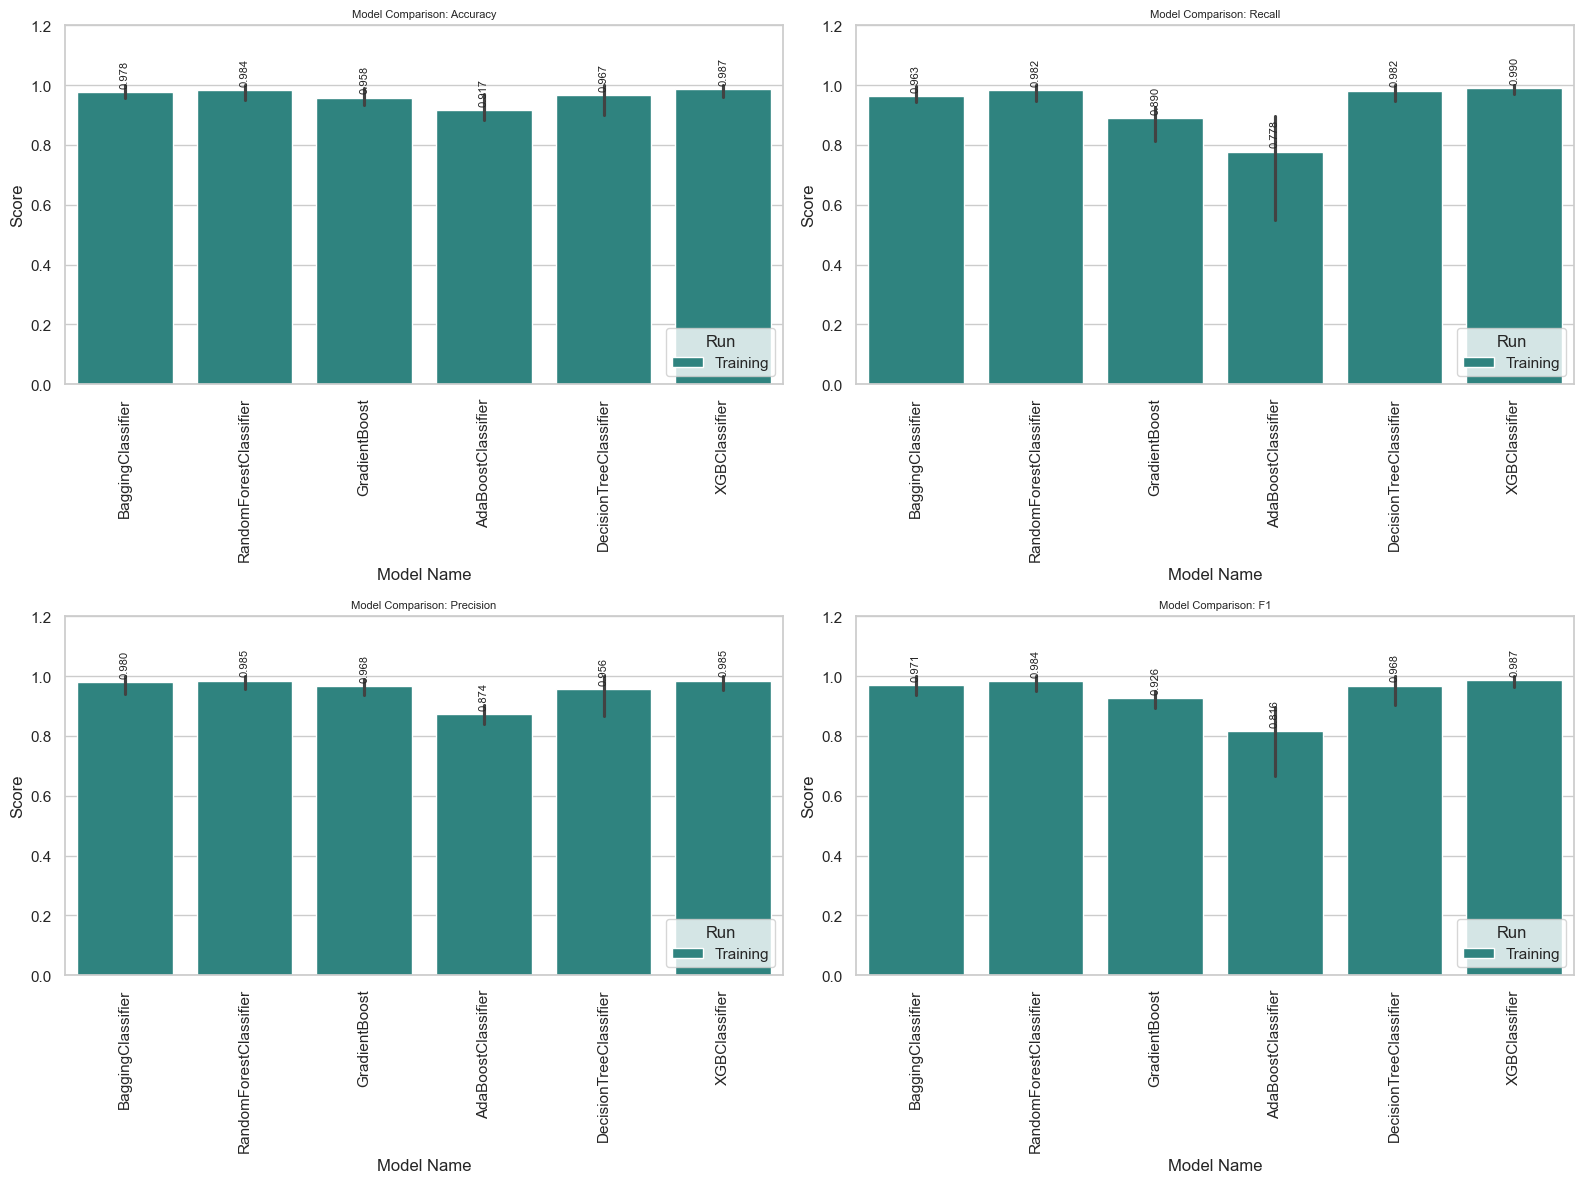

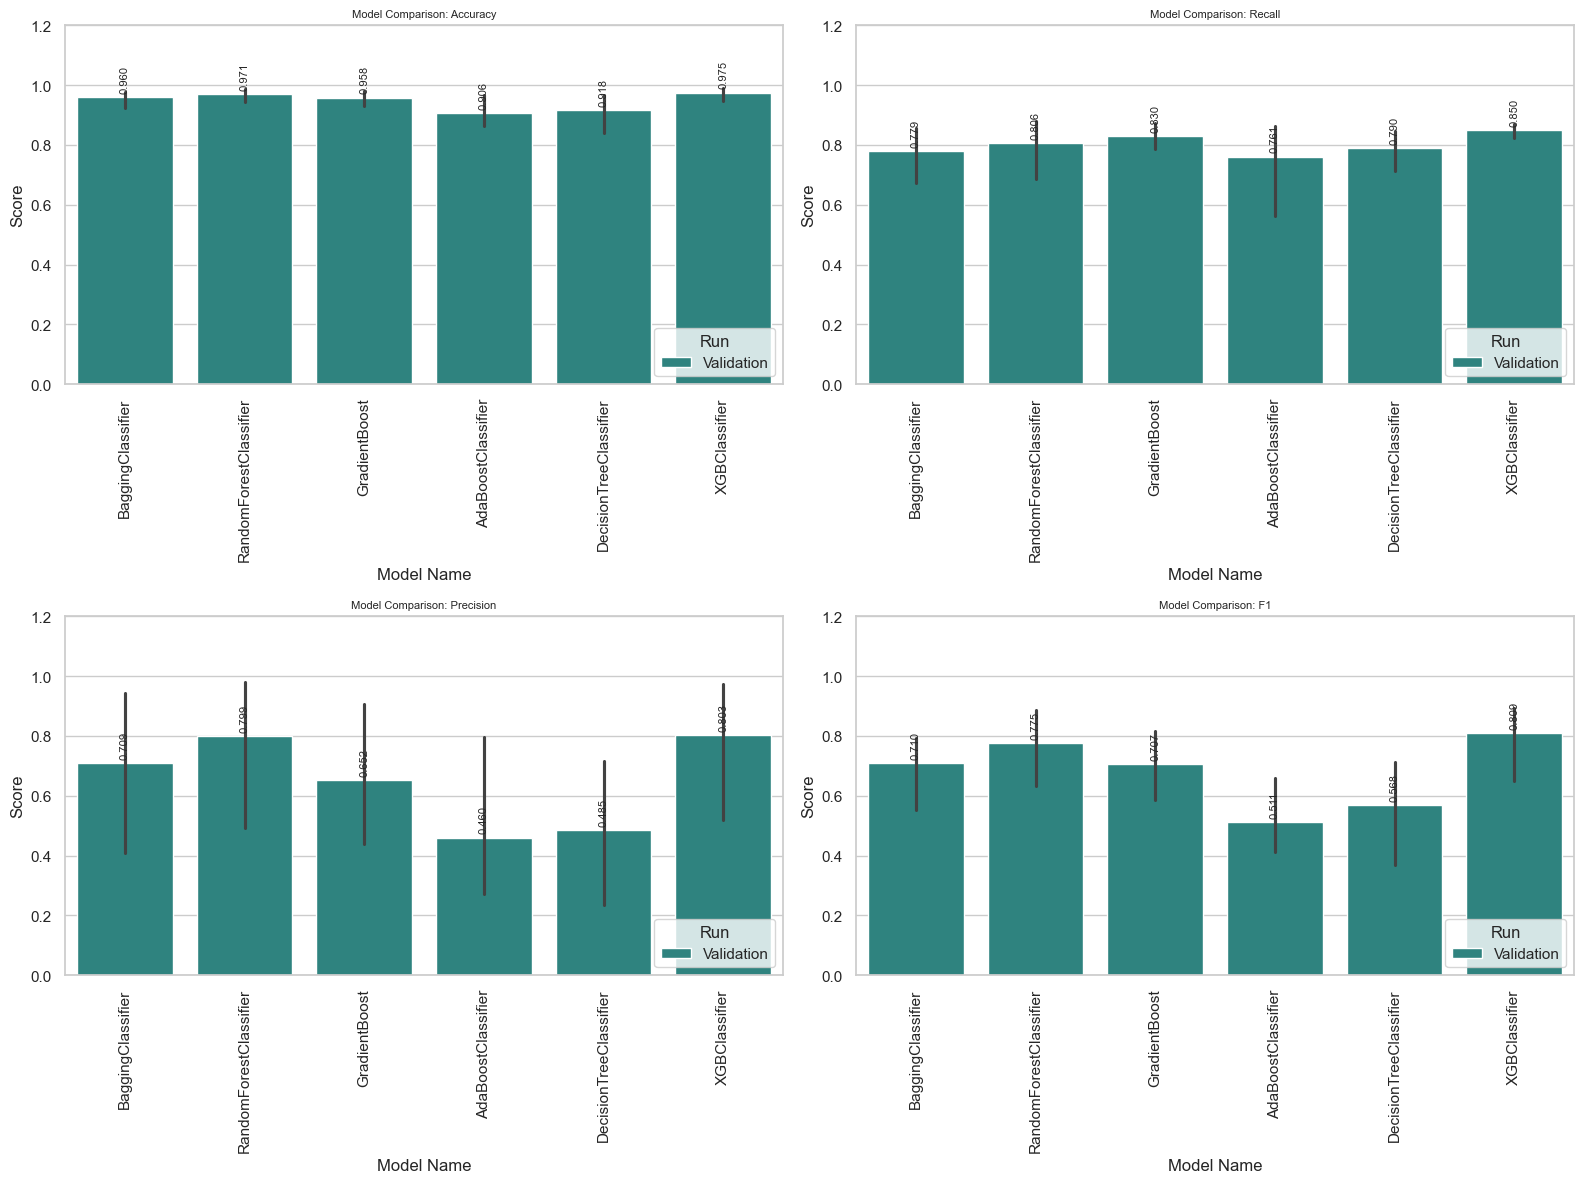

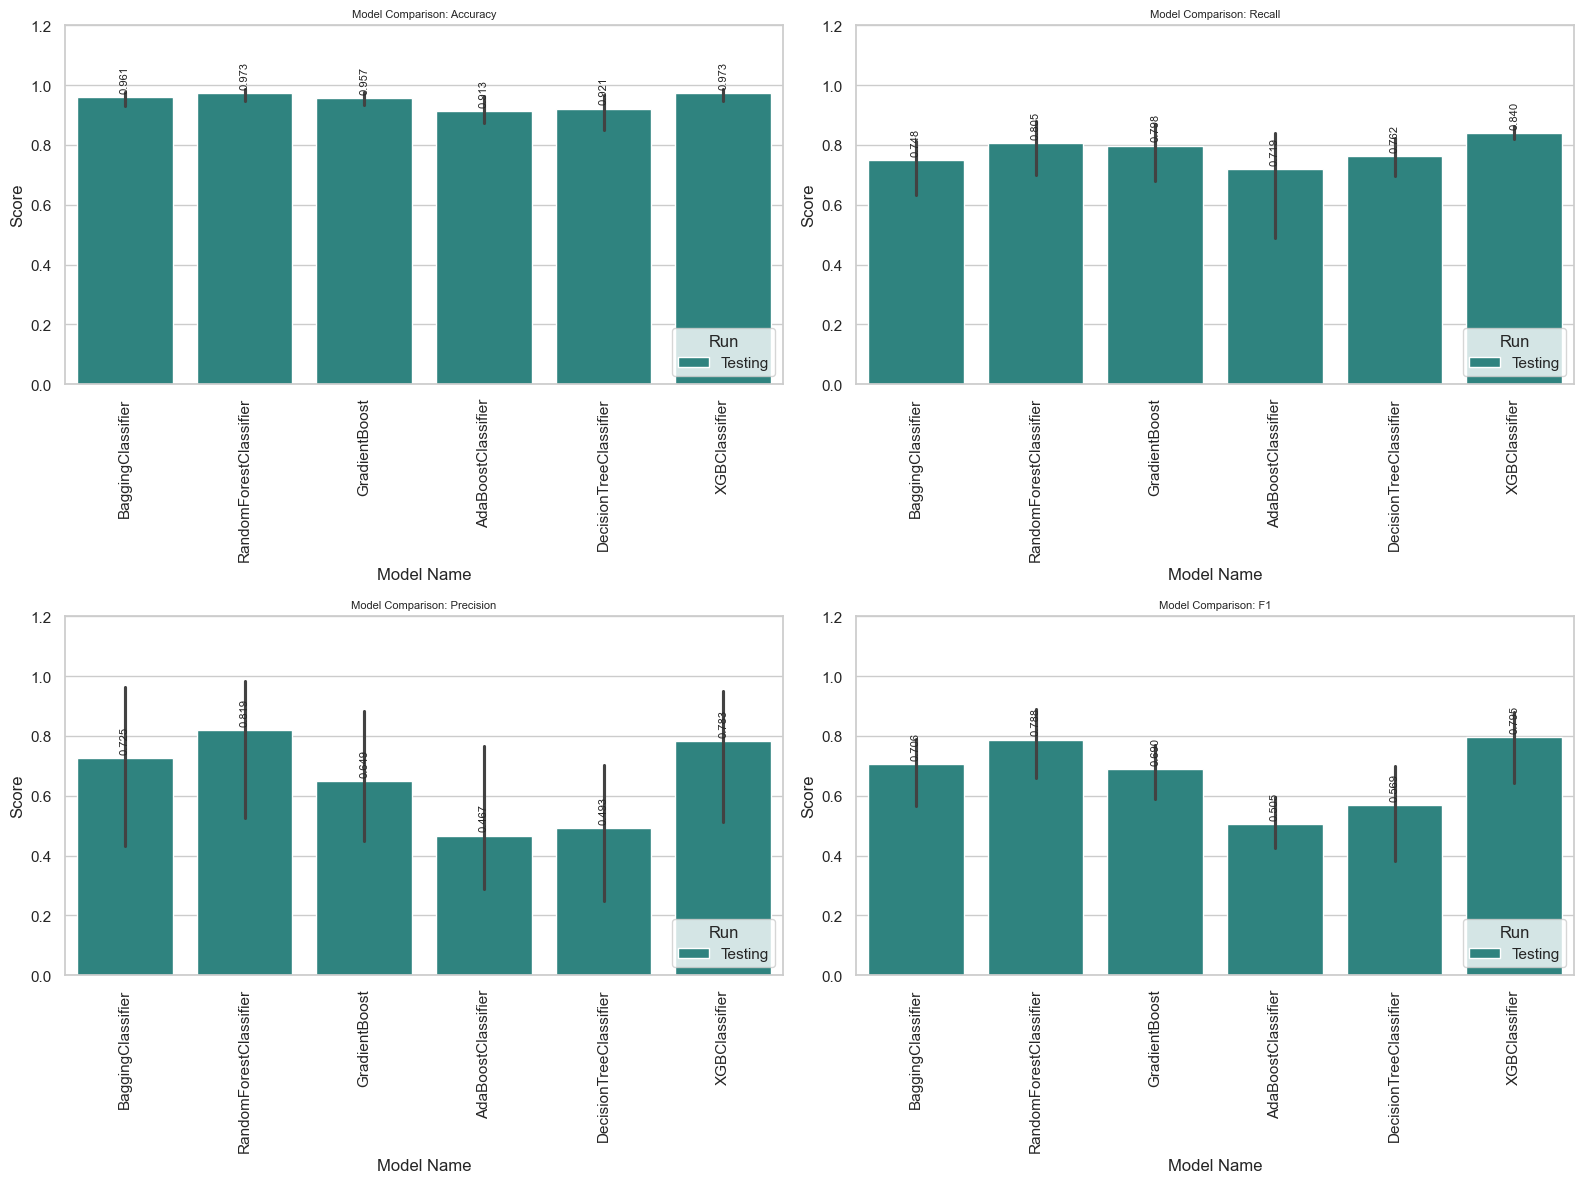

In [32]:
for model_type in ml_model_results['Run'].unique():
    showgraph(ml_model_results[ml_model_results["Run"] == model_type], title="Model Comparison - Original Data")


#### Hyper Tuning

In [ ]:
# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

param_grid_gradientboost = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}


param_grid_Adaboost = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
param_grid_bagging = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
       
param_grid_randomforest = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

param_grid_decisiontree = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
   
param_grid_xgboost={
    'n_estimators':np.arange(50,110,25),
    'scale_pos_weight':[1,2,5],
    'learning_rate':[0.01,0.1,0.05],
    'gamma':[1,3],
    'subsample':[0.7,0.9]
}

In [ ]:
ml_models_tuned = []

ml_models_tuned.append(("BaggingClassifier",BaggingClassifier(estimator=DecisionTreeClassifier(random_state=VKPy.RANDOM_STATE,class_weight='balanced'),random_state=VKPy.RANDOM_STATE),param_grid_bagging))
ml_models_tuned.append(('RandomForestClassifier', RandomForestClassifier(random_state=VKPy.RANDOM_STATE,class_weight='balanced'),param_grid_randomforest))
ml_models_tuned.append(('GradientBoost',  GradientBoostingClassifier(random_state=VKPy.RANDOM_STATE),param_grid_gradientboost))
ml_models_tuned.append(('AdaBoostClassifier', AdaBoostClassifier(random_state=VKPy.RANDOM_STATE),param_grid_Adaboost))
ml_models_tuned.append(('DecisionTreeClassifier', DecisionTreeClassifier(random_state=VKPy.RANDOM_STATE),param_grid_decisiontree))
ml_models_tuned.append(('XGBClassifier', XGBClassifier(random_state= VKPy.RANDOM_STATE,eval_metric="logloss"),param_grid_xgboost))


### Neural Network Models

#### Model Evaluation Criterion

#### **Observation Notes** :
The nature of predictions made by the classification model will translate as follows:
- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

Based, on this, FN is what I should be minimizing. Hence, i'm focused on the Recall metric

For highly imbalanced dataset like this one. 
- Accuracy is biased, and so is weighted average. Therefore, they are not suitable to be used for final model evaluation
- Since, MACRO average treats ALL CLASSES EQUALLY, it is a good metric to use for highly imbalanced dataset, where the minority class is IMPORTANT.
- SO, in conclusion, I choose to first focus on MACRO RECALL (FOR THE MINORITY CLASS), and, if the scores are very close to each other, I'll be choosing the model with the highest the MACRO F1.

Averaging is availble for classification metrics, as 
    * If "micro", compute metrics globally by counting the total true positives, false negatives and false positives. 
    * If "macro", compute metrics for each label, and return their unweighted mean. This does not take label imbalance into account. 
    * If "weighted", compute metrics for each label, and return their average weighted by support 
    * This alters "macro" to account for label imbalance. It can result in an score that is not between precision and recall.

**Note**:
* Selecting "macro" or "weighted" can be a better option for imbalanced datasets like this one. 
* The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
* <mark>Selecting the best model is based on the MACRO RECALL, and, if the scores are very close to each other, I'll be choosing the model with the highest the MACRO F1.</mark>

####

In [ ]:
# defining the batch size and # epochs upfront as we'll be using the same values for all models
EPOCHS = 10   
BATCH_SIZE = 10

LOSSTYPE = keras.losses.BinaryCrossentropy() # 'binary_crossentropy'
OPTMIZATION_METRICS= [keras.metrics.Recall(name='Recall'),
                      keras.metrics.F1Score(name='F1Score',average='macro',threshold=THRESHOLD)] 
TARGET_NAMES = ['No failure','Failure']

#Results collector
results = pd.DataFrame()

"""
# Build a function to show the graph of each model
"""
def compare_metrics(dataframe, metrics_to_compare, title="", savefig=False):
    """
    Generates a grid of bar charts to compare models across multiple metrics.
    """
    num_metrics = len(metrics_to_compare)
    # Determine grid size (2 columns)
    rows = (num_metrics + 1) // 2
    fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(20, 6 * rows))
    axes = axes.flatten()
    
    for i, column in enumerate(metrics_to_compare):
        # Sorting for better comparison
        df_sorted = dataframe.sort_values(by=column, ascending=True)
        #df_sorted = dataframe
        ax = axes[i]
        
        # Use rank-based normalization for better color distribution
        values = df_sorted[column]
        ranks = values.rank(method='dense')
        
        # Normalize ranks to 0-1 range
        min_rank = ranks.min()
        max_rank = ranks.max()
        
        if max_rank - min_rank != 0:
            normalized = (ranks - min_rank) / (max_rank - min_rank)
        else:
            normalized = [0.5] * len(values)
        
        # Create color map (Oranges colormap for gradient)
        cmap = plt.cm.coolwarm
        colors = [cmap(0.1 + 0.9 * val) for val in normalized]  # Range from 0.3 to 1.0 for better visibility
        
        bars = ax.bar(df_sorted['ModelName'], df_sorted[column], color=colors)
        ax.set_title(f'Comparison: {column}', fontweight='bold')
        ax.set_ylabel('Value')
        
        # Rotate X-axis labels by 90 degrees
        ax.tick_params(axis='x', labelrotation=90)
        
        # Calculate Y-axis limits with 1 standard deviation padding
        min_val = values.min()
        max_val = values.max()
        std_val = values.std()
        ax.set_ylim(min_val - std_val, max_val + std_val)
        
        # Determine format based on precision in data
        # Check if all values are integers (precision is zero)
        has_decimals = (df_sorted[column] % 1 != 0).any()
        format_str = '{:.4f}' if has_decimals else '{:.0f}'
        
        # Annotate bars with their values
        for bar in bars:
            yval = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, yval, format_str.format(yval), 
                    ha='center', va='bottom', fontsize=8)
            
    # Hide empty subplots if the number of metrics is odd
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    
    plt.tight_layout()
    
    if savefig:
        plt.savefig(f'{title}_comprehensive_model_comparison.png')
    plt.show()


#### S1 - SGD,relu,H1,O-sig- No class weights, no dropout

In [ ]:
model = Sequential()
model.add(Dense(units=32 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
                                optimizer = tf.keras.optimizers.SGD(), 
                                model_name="S1-UNSCALED", 
                                data = {"X_train":X_train, "y_train":y_train, "X_val": X_val, "y_val": y_val},
                                class_weights=None, 
                                loss_type = LOSSTYPE, 
                                optmization_metrics=OPTMIZATION_METRICS, 
                                threshold=THRESHOLD, 
                                target_names=TARGET_NAMES, 
                                epochs=EPOCHS, 
                                batch_size=BATCH_SIZE, 
                                print_model_summary=True,
                                verbose=1,
                            )
    
results = pd.concat([results,model_results])


model = Sequential()
model.add(Dense(units=32 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
                                optimizer = tf.keras.optimizers.SGD(), 
                                model_name="S1-SCALED", 
                                data = {"X_train":X_train_scaled, "y_train":y_train, "X_val": X_val_scaled, "y_val": y_val},
                                class_weights=None, 
                                loss_type = LOSSTYPE, 
                                optmization_metrics=OPTMIZATION_METRICS, 
                                threshold=THRESHOLD, 
                                target_names=TARGET_NAMES, 
                                epochs=EPOCHS, 
                                batch_size=BATCH_SIZE, 
                                print_model_summary=True,
                                verbose=1,
                            )
    
results = pd.concat([results,model_results])



#### S2 - SGD,relu,H1,H2,O-sig- No class weights, no dropout

In [ ]:
model = Sequential()
model.add(Dense(units=32 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
model.add(Dense(units=16,name='H2',activation="relu"))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.SGD(), 
            model_name="S2-UNSCALED", 
            data = {"X_train":X_train, "y_train":y_train, "X_val": X_val, "y_val": y_val},
            class_weights=None, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])


model = Sequential()
model.add(Dense(units=32 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
model.add(Dense(units=16,name='H2',activation="relu"))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.SGD(), 
            model_name="S2-SCALED", 
            data = {"X_train":X_train_scaled, "y_train":y_train, "X_val": X_val_scaled, "y_val": y_val},
            class_weights=None, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])

### S5D - SGD,relu,H1,D1,H2,D2,H3,O-sig- No class weights

In [ ]:
model = Sequential()
model.add(Dense(units=32 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.1,name="D1"))
model.add(Dense(units=16,name='H2',activation="relu"))
model.add(Dropout(0.1,name="D2"))
model.add(Dense(units=8,name ="H3", activation='relu'))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.SGD(), 
            model_name="S5D-UNSCALED", 
            data = {"X_train":X_train, "y_train":y_train, "X_val": X_val, "y_val": y_val},
            class_weights=None, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])

model = Sequential()
model.add(Dense(units=32 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.1,name="D1"))
model.add(Dense(units=16,name='H2',activation="relu"))
model.add(Dropout(0.1,name="D2"))
model.add(Dense(units=8,name ="H3", activation='relu'))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.SGD(), 
            model_name="S5D-SCALED", 
            data = {"X_train":X_train_scaled, "y_train":y_train, "X_val": X_val_scaled, "y_val": y_val},
            class_weights=None, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])

### S3 - SGD,relu,H1,H2,H3,O-Sig - No class weights

In [ ]:
model = Sequential()
model.add(Dense(units=64,name ='H1',activation="relu",input_dim=X_train.shape[1]))
model.add(Dense(units=32,name='H2',activation="relu"))
model.add(Dense(units=16,name='H3',activation="relu"))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.SGD(), 
            model_name="S3-UNSCALED", 
            data = {"X_train":X_train, "y_train":y_train, "X_val": X_val, "y_val": y_val},
            class_weights=None, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])


model = Sequential()
model.add(Dense(units=64,name ='H1',activation="relu",input_dim=X_train.shape[1]))
model.add(Dense(units=32,name='H2',activation="relu"))
model.add(Dense(units=16,name='H3',activation="relu"))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.SGD(), 
            model_name="S3-SCALED", 
            data = {"X_train":X_train_scaled, "y_train":y_train, "X_val": X_val_scaled, "y_val": y_val},
            class_weights=None, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])

### Compute Class Weights

In [ ]:
# Calculate class weights for imbalanced dataset
weights = (y_train.shape[0]) / np.bincount(y_train.astype(int)) # Convert y_train to integers
print(weights)

# Create a dictionary mapping class indices to their respective class weights
class_weights = {
    0: weights[0],
    1: weights[1]
}
display("Class Weights",class_weights)

### S5D-CW - SGD,relu,H1,D1,H2,D2,H3,O-Sig - class weights

In [ ]:
model = Sequential()
model.add(Dense(units=32 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.1,name="D1"))
model.add(Dense(units=16,name='H2',activation="relu"))
model.add(Dropout(0.1,name="D2"))
model.add(Dense(units=8,name ="H3", activation='relu'))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.SGD(), 
            model_name="S5D-CW-UNSCALED", 
            data = {"X_train":X_train, "y_train":y_train, "X_val": X_val, "y_val": y_val},
            class_weights=class_weights, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])


model = Sequential()
model.add(Dense(units=32 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.1,name="D1"))
model.add(Dense(units=16,name='H2',activation="relu"))
model.add(Dropout(0.1,name="D2"))
model.add(Dense(units=8,name ="H3", activation='relu'))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.SGD(), 
            model_name="S5D-CW-SCALED", 
            data = {"X_train":X_train_scaled, "y_train":y_train, "X_val": X_val_scaled, "y_val": y_val},
            class_weights=class_weights, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])


### A2-CW - Adam,relu,H1,H2,O-Sig - class weights

In [ ]:
model = Sequential()
model.add(Dense(units=32 ,name ='H1',activation="relu", input_dim=X_train.shape[1]))
model.add(Dense(units=16,name ="H2", activation='relu'))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.Adam(), 
            model_name="A2-CW", 
            data = {"X_train":X_train, "y_train":y_train, "X_val": X_val, "y_val": y_val},
            class_weights=class_weights, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])


### A5D-LR-CW - Adam,leaky_relu,H1,D1,H2,D2,H3,O-Sig - class weights

In [ ]:
model = Sequential()
model.add(Dense(units=32 ,name ='H1',activation="leaky_relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.1,name="D1"))
model.add(Dense(units=16,name='H2',activation="leaky_relu"))
model.add(Dropout(0.1,name="D2"))
model.add(Dense(units=8,name ="H3", activation='leaky_relu'))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.Adam(), 
            model_name="A5D-LR-CW", 
            data = {"X_train":X_train, "y_train":y_train, "X_val": X_val, "y_val": y_val},
            class_weights=class_weights, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])

### A5D-CW - Adam,relu,H1,D1,H2,D2,H3,O-Sig - class weights

In [ ]:
model = Sequential()
model.add(Dense(units=32 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.1,name="D1"))
model.add(Dense(units=16,name='H2',activation="relu"))
model.add(Dropout(0.1,name="D2"))
model.add(Dense(units=8,name ="H3", activation='relu'))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.Adam(), 
            model_name="A5D-CW-UNSCALED", 
            data = {"X_train":X_train, "y_train":y_train, "X_val": X_val, "y_val": y_val},
            class_weights=class_weights, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])

model = Sequential()
model.add(Dense(units=32 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.1,name="D1"))
model.add(Dense(units=16,name='H2',activation="relu"))
model.add(Dropout(0.1,name="D2"))
model.add(Dense(units=8,name ="H3", activation='relu'))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.Adam(), 
            model_name="A5D-CW-SCALED", 
            data = {"X_train":X_train_scaled, "y_train":y_train, "X_val": X_val_scaled, "y_val": y_val},
            class_weights=class_weights, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])

### A11D-CW - Adam,Relu,H1,D1,H2,D2,H3,H4,D4,H5,D5,H6,O-Sig - class weights

In [ ]:
model = Sequential()
model.add(Dense(units=256 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.1,name="D1"))
model.add(Dense(units=128,name='H2',activation="relu"))
model.add(Dropout(0.1,name="D2"))
model.add(Dense(units=64,name ="H3", activation='relu'))
model.add(Dropout(0.1,name="D3"))
model.add(Dense(units=32,name ="H4", activation='relu'))
model.add(Dropout(0.1,name="D4"))
model.add(Dense(units=16,name ="H5", activation='relu'))
model.add(Dropout(0.1,name="D5"))
model.add(Dense(units=8,name ="H6", activation='relu'))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.Adam(), 
            model_name="A11D-CW-UNSCALED", 
            data = {"X_train":X_train, "y_train":y_train, "X_val": X_val, "y_val": y_val},
            class_weights=class_weights, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])

model = Sequential()
model.add(Dense(units=256 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.1,name="D1"))
model.add(Dense(units=128,name='H2',activation="relu"))
model.add(Dropout(0.1,name="D2"))
model.add(Dense(units=64,name ="H3", activation='relu'))
model.add(Dropout(0.1,name="D3"))
model.add(Dense(units=32,name ="H4", activation='relu'))
model.add(Dropout(0.1,name="D4"))
model.add(Dense(units=16,name ="H5", activation='relu'))
model.add(Dropout(0.1,name="D5"))
model.add(Dense(units=8,name ="H6", activation='relu'))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.Adam(), 
            model_name="A11D-CW-SCALED", 
            data = {"X_train":X_train_scaled, "y_train":y_train, "X_val": X_val_scaled, "y_val": y_val},
            class_weights=class_weights, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])

### AX5D-CW - Adamx,H1,D1,H2,D2,H3,O-Sig - class weights

In [ ]:
model = Sequential()
model.add(Dense(units=64 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.1,name="D1"))
model.add(Dense(units=32,name='H2',activation="relu"))
model.add(Dropout(0.1,name="D2"))
model.add(Dense(units=16,name ="H3", activation='relu'))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.Adamax(), 
            model_name="AX5D-CW-UNSCALED", 
            data = {"X_train":X_train, "y_train":y_train, "X_val": X_val, "y_val": y_val},
            class_weights=class_weights, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])


model = Sequential()
model.add(Dense(units=64 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.1,name="D1"))
model.add(Dense(units=32,name='H2',activation="relu"))
model.add(Dropout(0.1,name="D2"))
model.add(Dense(units=16,name ="H3", activation='relu'))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.Adamax(), 
            model_name="AX5D-CW-SCALED", 
            data = {"X_train":X_train_scaled, "y_train":y_train, "X_val": X_val_scaled, "y_val": y_val},
            class_weights=class_weights, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])

### AX1-CW- Adamx,H1,O-Sig - class weights

In [ ]:
model = Sequential(name="AX1-CW-UNSCALED")
model.add(Dense(units=16,name ="H1", activation='relu'))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.Adamax(), 
            model_name="AX1-CW-UNSCALED", 
            data = {"X_train":X_train, "y_train":y_train, "X_val": X_val, "y_val": y_val},
            class_weights=class_weights, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])


model = Sequential()
model.add(Dense(units=16,name ="H1", activation='relu'))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.Adamax(), 
            model_name="AX1-CW-SCALED", 
            data = {"X_train":X_train_scaled, "y_train":y_train, "X_val": X_val_scaled, "y_val": y_val},
            class_weights=class_weights, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])

### AX9D-CW - Adamx,H1,D1,H2,D2,H3,D3,H4,D4,H5,O-Sig - class weights

In [ ]:
model = Sequential(name="AX9D-CW-UNSCALED")
model.add(Dense(units=256 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.1,name="D1"))
model.add(Dense(units=128 ,name ='H2',activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.1,name="D2"))
model.add(Dense(units=64 ,name ='H3',activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.1,name="D3"))
model.add(Dense(units=32,name='H4',activation="relu"))
model.add(Dropout(0.1,name="D4"))
model.add(Dense(units=16,name ="H5", activation='relu'))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.Adamax(), 
            model_name="AX9D-CW-UNSCALED", 
            data = {"X_train":X_train, "y_train":y_train, "X_val": X_val, "y_val": y_val},
            class_weights=class_weights, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])


model = Sequential(name="AX9D-CW-SCALED")
model.add(Dense(units=256 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.1,name="D1"))
model.add(Dense(units=128 ,name ='H2',activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.1,name="D2"))
model.add(Dense(units=64 ,name ='H3',activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.1,name="D3"))
model.add(Dense(units=32,name='H4',activation="relu"))
model.add(Dropout(0.1,name="D4"))
model.add(Dense(units=16,name ="H5", activation='relu'))
model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

model_results = MLM.execute_model(model_in = model,
            optimizer = tf.keras.optimizers.Adamax(), 
            model_name="AX9D-CW-SCALED", 
            data = {"X_train":X_train_scaled, "y_train":y_train, "X_val": X_val_scaled, "y_val": y_val},
            class_weights=class_weights, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )
results = pd.concat([results,model_results])

# **Model Performance Comparison and Final Model Selection**

### Check output 

In [ ]:
display(results)
pd.to_pickle(results, 'results.pkl')

In [ ]:
results = pd.read_pickle('results.pkl')
metrics = [ 
            'Train_F1Score', 
            'Validation_F1Score',
           
            'Train_Recall', 
            'Validation_Recall', 
        
            'Validation_Macro_Recall',
            'Validation_Macro_F1Score',
            

            'Train_Precision', 
            'Validation_Precision', 

            'Time', 
            'TotalParameters',

            'Train_Accuracy', 
            'Validation_Accuracy', 

            'Validation_Weighted_Precision',
            'Validation_Weighted_Recall',
            'Validation_Weighted_F1Score',
            'Validation_Macro_Precision',

            ]
compare_metrics(results, metrics)

### **Model Performance Comaprision**
Based on the comprehensive data and the visualizations provided, here is a summary and comparison of the models developed to predict wind turbine failures.

Since our primary goal is to **reduce false negatives**, the key metric is **Recall** (the model's ability to identify all actual failures). A higher recall ensures that fewer failures are missed, which is critical for predictive maintenance.

#### Comparison and Performance Analysis
The models vary by architecture (number of layers), optimization algorithm (SGD, Adam, Adamax), and whether they utilized **Class Weights** to handle the likely imbalanced nature of failure data.

##### 1. The Recall Leaders (False Negative Reduction)
Models utilizing the **Adamax** and **Adam** optimizers with **Class Weights (CW)** generally produced the highest Recall scores, though often at a slight cost to Precision.
* AX9D-CW-SCALED: Achieved the highest validation recall in the dataset (**~0.946**).
* A11D-CW-SCALED: Followed closely with a recall of **~0.945**.
* A5D-CW-SCALED: Showed strong balance with a recall of **~0.941**.

##### 2. Scaled vs. Unscaled Data
In almost all instances, models trained on **Scaled** data performed more consistently or outperformed their unscaled counterparts in generalization. Scaling is crucial for neural networks to prevent features with larger ranges from dominating the weight updates.

##### 3. Optimizer Impact
* **SGD (Stochastic Gradient Descent):** Models like **S3-UNSCALED** achieved high overall accuracy but generally lower recall compared to those using Class Weights.
* **Adam/Adamax:** These adaptive optimizers, when paired with Class Weights, were significantly more effective at "hunting" for the minority class (the failures).

#### The Top Model Selection
To reduce false negatives while maintaining high overall reliability, the top model is:
##### **AX9D-CW-SCALED**
| Metric | Value |
| --- | --- |
| Validation Recall | 0.9462 (Best for reducing false negatives) |
| Validation Accuracy | 0.9865 |
| Validation F1-Score | 0.9369 |
| Total Parameters | 54,273 |



### Final Model Checks and Tuning
Now, let's check the performance of the final model on the test set.

#### New Model with AX9D-CW-SCALED hyperparameters.

In [ ]:
tf.keras.backend.clear_session()

turbine_results = pd.DataFrame()

turbine_model = Sequential(name="AX9D-CW-SCALED-1")
turbine_model.add(Dense(units=256 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
turbine_model.add(Dropout(0.1,name="D1"))
turbine_model.add(Dense(units=128 ,name ='H2',activation="relu",input_dim=X_train.shape[1]))
turbine_model.add(Dropout(0.1,name="D2"))
turbine_model.add(Dense(units=64 ,name ='H3',activation="relu",input_dim=X_train.shape[1]))
turbine_model.add(Dropout(0.1,name="D3"))
turbine_model.add(Dense(units=32,name='H4',activation="relu"))
turbine_model.add(Dropout(0.1,name="D4"))
turbine_model.add(Dense(units=16,name ="H5", activation='relu'))
turbine_model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

turbine_result = MLM.execute_model(model_in = turbine_model,
            optimizer = tf.keras.optimizers.Adamax(), 
            model_name="AX9D-CW-SCALED-1", 
            data = {"X_train":X_train_scaled, "y_train":y_train, "X_val": X_val_scaled, "y_val": y_val},
            class_weights=class_weights, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            print_model_summary=True,
            verbose=1,
        )

turbine_results = pd.concat([turbine_results, turbine_result], ignore_index=True)




#### New Model based on AX9D-CW-SCALED hyper parameters, but increase the number of epochs to 25, and batch size to 100

In [ ]:
tf.keras.backend.clear_session()

turbine_model = Sequential(name="AX9D-CW-SCALED-2")
turbine_model.add(Dense(units=256 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
turbine_model.add(Dropout(0.1,name="D1"))
turbine_model.add(Dense(units=128 ,name ='H2',activation="relu",input_dim=X_train.shape[1]))
turbine_model.add(Dropout(0.1,name="D2"))
turbine_model.add(Dense(units=64 ,name ='H3',activation="relu",input_dim=X_train.shape[1]))
turbine_model.add(Dropout(0.1,name="D3"))
turbine_model.add(Dense(units=32,name='H4',activation="relu"))
turbine_model.add(Dropout(0.1,name="D4"))
turbine_model.add(Dense(units=16,name ="H5", activation='relu'))
turbine_model.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))

turbine_result = MLM.execute_model(model_in = turbine_model,
            optimizer = tf.keras.optimizers.Adamax(), 
            model_name="AX9D-CW-SCALED-2", 
            data = {"X_train":X_train_scaled, "y_train":y_train, "X_val": X_val_scaled, "y_val": y_val},
            class_weights=class_weights, 
            loss_type = LOSSTYPE, 
            optmization_metrics=OPTMIZATION_METRICS, 
            threshold=THRESHOLD, 
            target_names=TARGET_NAMES, 
            epochs=EPOCHS +15, 
            batch_size=BATCH_SIZE*10, 
            print_model_summary=True,
            verbose=1,
        )

turbine_results = pd.concat([turbine_results, turbine_result], ignore_index=True)



In [ ]:
turbine_results

In [ ]:
compare_metrics(turbine_results, metrics)

In [ ]:
# Programmatic stop 
# raise Exception("Stop here")
good_model = turbine_results[turbine_results['ModelName']=='AX9D-CW-SCALED-2']['Model'].iloc[0]

MLM.plot_confusion_matrix(model=good_model,predictors=X_test,expected=y_test,convert_pred_to_binary=True,threshold=0.5,title="Test the Top model with unscaled test data")
MLM.model_performance_classification(model=good_model,predictors=X_test,expected=y_test,score_average='binary',printall=True,title="Test the Top model with unscaled test data")

tf.keras.backend.clear_session()
good_model_scaled = turbine_results[turbine_results['ModelName']=='AX9D-CW-SCALED-2']['Model'].iloc[0]
MLM.plot_confusion_matrix(model=good_model_scaled,predictors=X_test_scaled,expected=y_test,convert_pred_to_binary=True,threshold=0.5, title="Test the Top model with scaled test data")
MLM.model_performance_classification(model=good_model_scaled,predictors=X_test_scaled,expected=y_test,score_average='binary',printall=True,title="Test the Top model with scaled test data")
# predictions=turbine_model.predict(X_test)


# **Actionable Insights and Recommendations**

**Why AX9D-CW-SCALED model?**
1. Highest Recall: It captures roughly **94.6%** of all failures, the best performance in the set.
2. Robust Architecture: With 10 layers and 54k parameters, it has the depth to understand complex failure patterns without being overly massive.
3. Balanced F1-Score: While it prioritizes recall, it doesn't sacrifice too much precision (it isn't just "guessing" failure constantly), maintaining a high F1-score of 0.936.

#### Key Observations
* **Class Weights are Mandatory:** Without Class Weights (the "CW" tag), the models tend to favor accuracy by predicting the "Normal" state correctly but missing the "Failure" state more often.
* **Diminishing Returns:** Increasing parameters from ~5k (S3) to ~54k (AX9D) provided a significant boost in recall, but further increases may lead to overfitting depending on your dataset size.

In predictive maintenance for wind turbines, a "False Negative" (missing a failure) is far more expensive than a "False Positive" (an unnecessary check). Here is how the other categories compared:

#### Comparison of Alternative Models
| Model Category | Key Weakness | Why it was rejected |
| --- | --- | --- |
| S-Series (SGD) | **Low Sensitivity** | Models like **S1** through **S5** used Stochastic Gradient Descent without Class Weights. While their accuracy was high (often >99%), their Recall was significantly lower (0.88–0.92). They are too "conservative" and would miss too many actual failures. |
| AX1-Series | **Underfitting** | These models (AX1-CW) have very few parameters (673). The data shows a massive drop in Recall (~0.91) and F1-Score (~0.78–0.80), indicating they are too simple to capture the complex patterns of turbine sensor data. |
| A11D-Series | **Diminishing Returns** | The **A11D-CW-SCALED** is a very strong runner-up with a Recall of **0.9456**. However, it uses 54,401 parameters. Compared to the selected model, it adds complexity without actually surpassing the Recall of the AX9D. |
| Unscaled Models | **Instability** | Models like **S5D-CW-UNSCALED** often showed lower performance than their "SCALED" counterparts. Neural networks converge more reliably when input features are on a similar scale. |

##### Why AX9D-CW-SCALED Won the "Trade-off"
Choosing a model is always a balance between **Precision** (avoiding false alarms) and **Recall** (avoiding missed failures).

##### The "Over-Conservative" Group (SGD Models)
These models are like a sensor that only goes off when it is 100% sure.
* Model: **S3-UNSCALED**
* Result: You save money on maintenance trips, but one day a turbine blade snaps because the model wasn't "brave" enough to flag the subtle vibration patterns.

##### The "Trigger Happy" Group (Small Adamax Models)
These models are like a sensor that goes off at every gust of wind.
* Model: **AX1-CW-SCALED**
* Result: You never miss a failure (Recall), but your maintenance team is exhausted and frustrated by constant false alarms (Precision is only ~0.72).
* The **AX9D-CW-SCALED** model represents the "elbow" of the performance curve. It achieved the highest recorded **Validation Recall (0.9462)**, meaning it is the most aggressive at catching failures, while still maintaining an **Accuracy of 98.6%**.
In this case, **Adding more batch size and number of epochs to the model will help in getting better results.

# Appendix 

### Alternative Approach
Just for fun, let's try a different approach to see if we can code differently, this is just repeated code to make more models, instead of using a libray to make models.

#### Model 0

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()
OPTIMIZER = tf.keras.optimizers.SGD() 

# Initializing the neural network
M0 = Sequential()
M0.add(Dense(units=32 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
M0.add(Dense(units=1 ,name ='OUT', activation="sigmoid"))
# Print Summary
M0.summary()

M0.compile(loss=LOSSTYPE, optimizer=OPTIMIZER, metrics = OPTMIZATION_METRICS )

M0_start = time.time()
M0_history = M0.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=BATCH_SIZE, epochs=EPOCHS)
M0_end=time.time()

M0_T_performance = MLM.model_performance_classification(model=M0, predictors=X_train, expected=y_train, threshold=THRESHOLD, score_average='macro', title="M0 Training Data")
M0_V_performance = MLM.model_performance_classification(model=M0, predictors=X_val, expected=y_val,threshold=THRESHOLD, score_average='macro',title="M0 Validation Data")

MLM.model_history_plot(M0_history, title = "M0 History")

#Check the predictions. 
M0_y_train_pred = M0.predict(X_train)
M0_y_val_pred = M0.predict(X_val)

#Collect Classification Reports - Train
M0_cr_train = classification_report(y_train,M0_y_train_pred>THRESHOLD,output_dict=True, digits=4, target_names=TARGET_NAMES)
print(M0_cr_train)
# Visualize using Seaborn
plt.figure(figsize=(3, 2))
sns.heatmap(pd.DataFrame(data=M0_cr_train).T.iloc[:-3, :-1], annot=True, cmap="Blues", fmt=".4f")
plt.title(f"M0 - CR Heatmap - Train")
plt.show()


# Visualize using Seaborn - Validation
M0_cr_val = classification_report(y_val,M0_y_val_pred>THRESHOLD,output_dict=True, digits=4, target_names=TARGET_NAMES)
plt.figure(figsize=(3, 2))
sns.heatmap(pd.DataFrame(data=M0_cr_val).T.iloc[:-3, :-1], annot=True, cmap="Blues", fmt=".4f")
plt.title("M0 CR Heatmap - Val")
plt.show()


results = pd.concat([results, pd.DataFrame(data={
            'ModelName':'M0',
            'Layers' : 1,
            'Epochs':EPOCHS,
            'BatchSize':BATCH_SIZE,
            'Activation':'relu',
            'Optimizer':'SGD',
            'Loss':'binary_crossentropy',
            'Metrics':'accuracy',
            'TotalParameters': M0.count_params(),
            'Model':M0,
            'History':M0_history,
            'Time':M0_end-M0_start,
            'T_Accuracy':M0_T_performance['Accuracy'].abs(),
            'T_Recall':M0_T_performance['Recall'].abs(),
            'T_Precision':M0_T_performance['Precision'].abs(),
            'T_F1Score':M0_T_performance['F1'].abs(),
            'V_Accuracy':M0_V_performance['Accuracy'].abs(),
            'V_Recall':M0_V_performance['Recall'].abs(),
            'V_Precision':M0_V_performance['Precision'].abs(),
            'V_F1Score':M0_V_performance['F1'].abs(),
        }
    )])

display(results)

#### M1 - SGD - 2 hidden layers (32,16 relu) - 1 output (sigmoid)

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()
OPTIMIZER = tf.keras.optimizers.SGD() 

# Initializing the neural network
M1 = Sequential()
M1.add(Dense(units=32 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
M1.add(Dense(units=16,name='H2',activation="relu"))
M1.add(Dense( 1 ,name ='OUT', activation="sigmoid"))
# Print Summary
M1.summary()

M1.compile(loss=LOSSTYPE, optimizer=OPTIMIZER, metrics = OPTMIZATION_METRICS )

M1_start = time.time()
M1_history = M1.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=BATCH_SIZE, epochs=EPOCHS)
M1_end=time.time()

M1_T_performance = MLM.model_performance_classification(model=M1, predictors=X_train, expected=y_train, threshold=THRESHOLD, score_average='macro', title="M1 Training Data")
M1_V_performance = MLM.model_performance_classification(model=M1, predictors=X_val, expected=y_val,threshold=THRESHOLD, score_average='macro',title="M1 Validation Data")

MLM.model_history_plot(M1_history, title = "M1 History")

#Check the predictions. 
M1_y_train_pred = M1.predict(X_train)
M1_y_val_pred = M1.predict(X_val)

#Collect Classification Reports - Train
M1_cr_train = classification_report(y_train,M1_y_train_pred>THRESHOLD,output_dict=True, digits=4, target_names=TARGET_NAMES)
print(M1_cr_train)
# Visualize using Seaborn
plt.figure(figsize=(3, 2))
sns.heatmap(pd.DataFrame(data=M1_cr_train).T.iloc[:-3, :-1], annot=True, cmap="Blues", fmt=".4f")
plt.title(f"M1 - CR Heatmap - Train")
plt.show()


# Visualize using Seaborn - Validation
M1_cr_val = classification_report(y_val,M1_y_val_pred>THRESHOLD,output_dict=True, digits=4, target_names=TARGET_NAMES)
plt.figure(figsize=(3, 2))
sns.heatmap(pd.DataFrame(data=M1_cr_val).T.iloc[:-3, :-1], annot=True, cmap="Blues", fmt=".4f")
plt.title("M1 CR Heatmap - Val")
plt.show()


results = pd.concat([results, pd.DataFrame(data={
                                    'ModelName':'M1',
                                    'Layers' : 2,
                                    'Epochs':EPOCHS,
                                    'BatchSize':BATCH_SIZE,
                                    'Activation':'relu',
                                    'Optimizer':'SGD',
                                    'Loss':'binary_crossentropy',
                                    'Metrics':'accuracy',
                                    'TotalParameters': M1.count_params(),
                                    'Model':M1,
                                    'History':M1_history,
                                    'Time':M1_end-M1_start,
                                    'T_Accuracy':M1_T_performance['Accuracy'].abs(),
                                    'T_Recall':M1_T_performance['Recall'].abs(),
                                    'T_Precision':M1_T_performance['Precision'].abs(),
                                    'T_F1Score':M1_T_performance['F1'].abs(),
                                    'V_Accuracy':M1_V_performance['Accuracy'].abs(),
                                    'V_Recall':M1_V_performance['Recall'].abs(),
                                    'V_Precision':M1_V_performance['Precision'].abs(),
                                    'V_F1Score':M1_V_performance['F1'].abs(),
                                    })
    ])

display(results)

#### M2 - SGD - 3 hidden layers (32,16,8 relu) - 1 dropout 0.1- 1 output (sigmoid)

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()
OPTIMIZER = tf.keras.optimizers.SGD() 

# Initializing the neural network
M2 = Sequential()
M2.add(Dense(units=32 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
M2.add(Dropout(0.1,name="D1"))
M2.add(Dense(units=16,name='H2',activation="relu"))
M2.add(Dense(units=8,name ="H3", activation='relu'))
M2.add(Dense( 1 ,name ='OUT', activation="sigmoid"))
# Print Summary
M2.summary()

M2.compile(loss=LOSSTYPE, optimizer=OPTIMIZER, metrics = OPTMIZATION_METRICS )

M2_start = time.time()
M2_history = M2.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=BATCH_SIZE, epochs=EPOCHS)
M2_end=time.time()

M2_T_performance = MLM.model_performance_classification(model=M2, predictors=X_train, expected=y_train, threshold=THRESHOLD, score_average='macro', title="M2 Training Data")
M2_V_performance = MLM.model_performance_classification(model=M2, predictors=X_val, expected=y_val,threshold=THRESHOLD, score_average='macro',title="M2 Validation Data")

MLM.model_history_plot(M2_history, title = "M2 History")

#Check the predictions. 
M2_y_train_pred = M2.predict(X_train)
M2_y_val_pred = M2.predict(X_val)

#Collect Classification Reports - Train
M2_cr_train = classification_report(y_train,M2_y_train_pred>THRESHOLD,output_dict=True, digits=4, target_names=TARGET_NAMES)
print(M2_cr_train)
# Visualize using Seaborn
plt.figure(figsize=(3, 2))
sns.heatmap(pd.DataFrame(data=M2_cr_train).T.iloc[:-3, :-1], annot=True, cmap="Blues", fmt=".4f")
plt.title(f"M2 - CR Heatmap - Train")
plt.show()


# Visualize using Seaborn - Validation
M2_cr_val = classification_report(y_val,M2_y_val_pred>THRESHOLD,output_dict=True, digits=4, target_names=TARGET_NAMES)
plt.figure(figsize=(3, 2))
sns.heatmap(pd.DataFrame(data=M2_cr_val).T.iloc[:-3, :-1], annot=True, cmap="Blues", fmt=".4f")
plt.title("M2 CR Heatmap - Val")
plt.show()


results = pd.concat([results, pd.DataFrame(data={
                                    'ModelName':'M2',
                                    'Layers' : 4,
                                    'Epochs':EPOCHS,
                                    'BatchSize':BATCH_SIZE,
                                    'Activation':'relu',
                                    'Optimizer':'SGD',
                                    'Loss':'binary_crossentropy',
                                    'Metrics':'accuracy',
                                    'TotalParameters': M2.count_params(),
                                    'Model':M2,
                                    'History':M2_history,
                                    'Time':M2_end-M2_start,
                                    'T_Accuracy':M2_T_performance['Accuracy'].abs(),
                                    'T_Recall':M2_T_performance['Recall'].abs(),
                                    'T_Precision':M2_T_performance['Precision'].abs(),
                                    'T_F1Score':M2_T_performance['F1'].abs(),
                                    'V_Accuracy':M2_V_performance['Accuracy'].abs(),
                                    'V_Recall':M2_V_performance['Recall'].abs(),
                                    'V_Precision':M2_V_performance['Precision'].abs(),
                                    'V_F1Score':M2_V_performance['F1'].abs(),
                                    })
    ])

display(results)

#### M3 - SGD - 3 hidden layers (32,16,8 relu) - 1 dropout 0.1- 1 output (sigmoid) - Class weight

In [ ]:
# Calculate class weights for imbalanced dataset
weights = (y_train.shape[0]) / np.bincount(y_train.astype(int)) # Convert y_train to integers
print(weights)

# Create a dictionary mapping class indices to their respective class weights
class_weights = {
    0: weights[0],
    1: weights[1]
}
display("Class Weights",class_weights)


In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()
OPTIMIZER = tf.keras.optimizers.SGD() 

# Initializing the neural network
M3 = Sequential()
M3.add(Dense(units=32 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
M3.add(Dropout(0.1,name="D1"))
M3.add(Dense(units=16,name='H2',activation="relu"))
M3.add(Dense(units=8,name ="H3", activation='relu'))
M3.add(Dense( 1 ,name ='OUT', activation="sigmoid"))
# Print Summary
M3.summary()

M3.compile(loss=LOSSTYPE, optimizer=OPTIMIZER, metrics = OPTMIZATION_METRICS )

M3_start = time.time()
M3_history = M3.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=BATCH_SIZE, epochs=EPOCHS,class_weight=class_weights,verbose=1)
M3_end=time.time()

M3_T_performance = MLM.model_performance_classification(model=M3, predictors=X_train, expected=y_train, threshold=THRESHOLD, score_average='macro', title="M3 Training Data")
M3_V_performance = MLM.model_performance_classification(model=M3, predictors=X_val, expected=y_val,threshold=THRESHOLD, score_average='macro',title="M3 Validation Data")

MLM.model_history_plot(M3_history, title = "M3 History")

#Check the predictions. 
M3_y_train_pred = M3.predict(X_train)
M3_y_val_pred = M3.predict(X_val)

#Collect Classification Reports - Train
M3_cr_train = classification_report(y_train,M3_y_train_pred>THRESHOLD,output_dict=True, digits=4, target_names=TARGET_NAMES)
print(M3_cr_train)
# Visualize using Seaborn
plt.figure(figsize=(3, 2))
sns.heatmap(pd.DataFrame(data=M3_cr_train).T.iloc[:-3, :-1], annot=True, cmap="Blues", fmt=".4f")
plt.title(f"M3 - CR Heatmap - Train")
plt.show()


# Visualize using Seaborn - Validation
M3_cr_val = classification_report(y_val,M3_y_val_pred>THRESHOLD,output_dict=True, digits=4, target_names=TARGET_NAMES)
plt.figure(figsize=(3, 2))
sns.heatmap(pd.DataFrame(data=M3_cr_val).T.iloc[:-3, :-1], annot=True, cmap="Blues", fmt=".4f")
plt.title("M3 CR Heatmap - Val")
plt.show()


results = pd.concat([results, pd.DataFrame(data={
                                    'ModelName':'M3',
                                    'Layers' : 4,
                                    'Epochs':EPOCHS,
                                    'BatchSize':BATCH_SIZE,
                                    'Activation':'relu',
                                    'Optimizer':'SGD',
                                    'Loss':'binary_crossentropy',
                                    'Metrics':'accuracy',
                                    'TotalParameters': M3.count_params(),
                                    'Model':M3,
                                    'History':M3_history,
                                    'Time':M3_end-M3_start,
                                    'T_Accuracy':M3_T_performance['Accuracy'].abs(),
                                    'T_Recall':M3_T_performance['Recall'].abs(),
                                    'T_Precision':M3_T_performance['Precision'].abs(),
                                    'T_F1Score':M3_T_performance['F1'].abs(),
                                    'V_Accuracy':M3_V_performance['Accuracy'].abs(),
                                    'V_Recall':M3_V_performance['Recall'].abs(),
                                    'V_Precision':M3_V_performance['Precision'].abs(),
                                    'V_F1Score':M3_V_performance['F1'].abs(),
                                    })
    ])

display(results)

#### M4 - Adam - 2 hidden layers (32,16 relu) - 1 output (sigmoid)

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()
OPTIMIZER = tf.keras.optimizers.Adam() 

# Initializing the neural network
M4 = Sequential()
M4.add(Dense(units=32 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
M4.add(Dense(units=16,name ="H2", activation='relu'))
M4.add(Dense( 1 ,name ='OUT', activation="sigmoid"))
# Print Summary
M4.summary()

M4.compile(loss=LOSSTYPE, optimizer=OPTIMIZER, metrics = OPTMIZATION_METRICS )

M4_start = time.time()
M4_history = M4.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=BATCH_SIZE, epochs=EPOCHS)
M4_end=time.time()

M4_T_performance = MLM.model_performance_classification(model=M4, predictors=X_train, expected=y_train, threshold=THRESHOLD, score_average='macro', title="M4 Training Data")
M4_V_performance = MLM.model_performance_classification(model=M4, predictors=X_val, expected=y_val,threshold=THRESHOLD, score_average='macro',title="M4 Validation Data")

MLM.model_history_plot(M4_history, title = "M4 History")

#Check the predictions. 
M4_y_train_pred = M4.predict(X_train)
M4_y_val_pred = M4.predict(X_val)

#Collect Classification Reports - Train
M4_cr_train = classification_report(y_train,M4_y_train_pred>THRESHOLD,output_dict=True, digits=4, target_names=TARGET_NAMES)
print(M4_cr_train)
# Visualize using Seaborn
plt.figure(figsize=(3, 2))
sns.heatmap(pd.DataFrame(data=M4_cr_train).T.iloc[:-3, :-1], annot=True, cmap="Blues", fmt=".4f")
plt.title(f"M4 - CR Heatmap - Train")
plt.show()


# Visualize using Seaborn - Validation
M4_cr_val = classification_report(y_val,M4_y_val_pred>THRESHOLD,output_dict=True, digits=4, target_names=TARGET_NAMES)
plt.figure(figsize=(3, 2))
sns.heatmap(pd.DataFrame(data=M4_cr_val).T.iloc[:-3, :-1], annot=True, cmap="Blues", fmt=".4f")
plt.title("M4 CR Heatmap - Val")
plt.show()


results = pd.concat([results, pd.DataFrame(data={
                                    'ModelName':'M4',
                                    'Layers' : 2,
                                    'Epochs':EPOCHS,
                                    'BatchSize':BATCH_SIZE,
                                    'Activation':'relu',
                                    'Optimizer':'Adam',
                                    'Loss':'binary_crossentropy',
                                    'Metrics':'accuracy',
                                    'TotalParameters': M4.count_params(),
                                    'Model':M4,
                                    'History':M4_history,
                                    'Time':M4_end-M4_start,
                                    'T_Accuracy':M4_T_performance['Accuracy'].abs(),
                                    'T_Recall':M4_T_performance['Recall'].abs(),
                                    'T_Precision':M4_T_performance['Precision'].abs(),
                                    'T_F1Score':M4_T_performance['F1'].abs(),
                                    'V_Accuracy':M4_V_performance['Accuracy'].abs(),
                                    'V_Recall':M4_V_performance['Recall'].abs(),
                                    'V_Precision':M4_V_performance['Precision'].abs(),
                                    'V_F1Score':M4_V_performance['F1'].abs(),
                                    })
    ])

display(results)

#### M5 - Adam - 3 hidden layers (32,16,8 relu) - 1 dropout 0.1- 1 output (sigmoid)

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()
OPTIMIZER = tf.keras.optimizers.Adam() 

# Initializing the neural network
M5 = Sequential()
M5.add(Dense(units=32 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
M5.add(Dropout(0.1,name="D1"))
M5.add(Dense(units=16,name='H2',activation="relu"))
M5.add(Dense(units=8,name ="H3", activation='relu'))
M5.add(Dense( 1 ,name ='OUT', activation="sigmoid"))
# Print Summary
M5.summary()

M5.compile(loss=LOSSTYPE, optimizer=OPTIMIZER, metrics = OPTMIZATION_METRICS )

M5_start = time.time()
M5_history = M5.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=BATCH_SIZE, epochs=EPOCHS,verbose=1)
M5_end=time.time()

M5_T_performance = MLM.model_performance_classification(model=M5, predictors=X_train, expected=y_train, threshold=THRESHOLD, score_average='macro', title="M5 Training Data")
M5_V_performance = MLM.model_performance_classification(model=M5, predictors=X_val, expected=y_val,threshold=THRESHOLD, score_average='macro',title="M5 Validation Data")

MLM.model_history_plot(M5_history, title = "M5 History")

#Check the predictions. 
M5_y_train_pred = M5.predict(X_train)
M5_y_val_pred = M5.predict(X_val)

#Collect Classification Reports - Train
M5_cr_train = classification_report(y_train,M5_y_train_pred>THRESHOLD,output_dict=True, digits=4, target_names=TARGET_NAMES)
print(M5_cr_train)
# Visualize using Seaborn
plt.figure(figsize=(3, 2))
sns.heatmap(pd.DataFrame(data=M5_cr_train).T.iloc[:-3, :-1], annot=True, cmap="Blues", fmt=".4f")
plt.title(f"M5 - CR Heatmap - Train")
plt.show()


# Visualize using Seaborn - Validation
M5_cr_val = classification_report(y_val,M5_y_val_pred>THRESHOLD,output_dict=True, digits=4, target_names=TARGET_NAMES)
plt.figure(figsize=(3, 2))
sns.heatmap(pd.DataFrame(data=M5_cr_val).T.iloc[:-3, :-1], annot=True, cmap="Blues", fmt=".4f")
plt.title("M5 CR Heatmap - Val")
plt.show()


results = pd.concat([results, pd.DataFrame(data={
                                    'ModelName':'M5',
                                    'Layers' : 4,
                                    'Epochs':EPOCHS,
                                    'BatchSize':BATCH_SIZE,
                                    'Activation':'relu',
                                    'Optimizer':'Adam',
                                    'Loss':'binary_crossentropy',
                                    'Metrics':'accuracy',
                                    'TotalParameters': M5.count_params(),
                                    'Model':M5,
                                    'History':M5_history,
                                    'Time':M5_end-M5_start,
                                    'T_Accuracy':M5_T_performance['Accuracy'].abs(),
                                    'T_Recall':M5_T_performance['Recall'].abs(),
                                    'T_Precision':M5_T_performance['Precision'].abs(),
                                    'T_F1Score':M5_T_performance['F1'].abs(),
                                    'V_Accuracy':M5_V_performance['Accuracy'].abs(),
                                    'V_Recall':M5_V_performance['Recall'].abs(),
                                    'V_Precision':M5_V_performance['Precision'].abs(),
                                    'V_F1Score':M5_V_performance['F1'].abs(),
                                    })
    ])

display(results)

#### M6 - Adam - 3 hidden layers (32,16,8 relu) - 1 dropout 0.1- 1 output (sigmoid) - class weights

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()
OPTIMIZER = tf.keras.optimizers.Adam() 

# Initializing the neural network
M6 = Sequential()
M6.add(Dense(units=32 ,name ='H1',activation="relu",input_dim=X_train.shape[1]))
M6.add(Dropout(0.1,name="D1"))
M6.add(Dense(units=16,name='H2',activation="relu"))
M6.add(Dense(units=8,name ="H3", activation='relu'))
M6.add(Dense( 1 ,name ='OUT', activation="sigmoid"))
# Print Summary
M6.summary()

M6.compile(loss=LOSSTYPE, optimizer=OPTIMIZER, metrics = OPTMIZATION_METRICS )

M6_start = time.time()
M6_history = M6.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=BATCH_SIZE, epochs=EPOCHS,class_weight=class_weights,verbose=1)
M6_end=time.time()

M6_T_performance = MLM.model_performance_classification(model=M6, predictors=X_train, expected=y_train, threshold=THRESHOLD, score_average='macro', title="M6 Training Data")
M6_V_performance = MLM.model_performance_classification(model=M6, predictors=X_val, expected=y_val,threshold=THRESHOLD, score_average='macro',title="M6 Validation Data")

MLM.model_history_plot(M6_history, title = "M6 History")

#Check the predictions. 
M6_y_train_pred = M6.predict(X_train)
M6_y_val_pred = M6.predict(X_val)

#Collect Classification Reports - Train
M6_cr_train = classification_report(y_train,M6_y_train_pred>THRESHOLD,output_dict=True, digits=4, target_names=TARGET_NAMES)
print(M6_cr_train)
# Visualize using Seaborn
plt.figure(figsize=(3, 2))
sns.heatmap(pd.DataFrame(data=M6_cr_train).T.iloc[:-3, :-1], annot=True, cmap="Blues", fmt=".4f")
plt.title(f"M6 - CR Heatmap - Train")
plt.show()


# Visualize using Seaborn - Validation
M6_cr_val = classification_report(y_val,M6_y_val_pred>THRESHOLD,output_dict=True, digits=4, target_names=TARGET_NAMES)
plt.figure(figsize=(3, 2))
sns.heatmap(pd.DataFrame(data=M6_cr_val).T.iloc[:-3, :-1], annot=True, cmap="Blues", fmt=".4f")
plt.title("M6 CR Heatmap - Val")
plt.show()


results = pd.concat([results, pd.DataFrame(data={
                                    'ModelName':'M6',
                                    'Layers' : 4,
                                    'Epochs':EPOCHS,
                                    'BatchSize':BATCH_SIZE,
                                    'Activation':'relu',
                                    'Optimizer':'Adam',
                                    'Loss':'binary_crossentropy',
                                    'Metrics':'accuracy',
                                    'TotalParameters': M6.count_params(),
                                    'Model':M6,
                                    'History':M6_history,
                                    'Time':M6_end-M6_start,
                                    'T_Accuracy':M6_T_performance['Accuracy'].abs(),
                                    'T_Recall':M6_T_performance['Recall'].abs(),
                                    'T_Precision':M6_T_performance['Precision'].abs(),
                                    'T_F1Score':M6_T_performance['F1'].abs(),
                                    'V_Accuracy':M6_V_performance['Accuracy'].abs(),
                                    'V_Recall':M6_V_performance['Recall'].abs(),
                                    'V_Precision':M6_V_performance['Precision'].abs(),
                                    'V_F1Score':M6_V_performance['F1'].abs(),
                                    })
    ])

display(results)